# ISM

In [192]:
# RUN IMPORT LIBRARIES
############################################################################################
import numpy as np
import scipy
import matplotlib.pyplot as plt
import os
import tifffile as tiff
# from PIL import Image
import h5py
from matplotlib.patches import Rectangle
from scipy.optimize import curve_fit
from skimage.feature import peak_local_max
import pandas as pd

import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.analysis.Tools_lib as tool
# from scipy.ndimage import fourier_shift, shift 
from os import path
import plotly.express as px
from time import time

In [193]:
file = 'Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2'  # buona QB
# Qdots_37mW_FOV5um_64x64_100rip_5msPixel # fototubo?
# Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_ROI8 # QD poco separati, molti analizzati alcuni con ottimi risultati
# Qdots_770nm_34mW_FOV3um_32x32_50rip_5msPixel_ROI7 # giga QD sfocato al centro
# Qdots_770nm_34mW_FOV5um_64x64_30rip_5msPixel_ROI5 # buona QB
# Qdots_770nm_34mW_FOV5um_64x64_50rip_5msPixel_ROI4 # sfocata a causa di movimento QD
# Qdots_770nm_34mW_FOV5um_64x64_60rip_2msPixel_ROI6 # sfocata e troppi QD, non analizzata del tutto
# Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2 # veramente ottima
# Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI3 # ni

In [194]:
# RUN INPUT
#############################################################################################

#############################################################################################
# FILE IMPORT AND SETUP
############################################################################################

dir = os.getcwd()
filename = path.join(dir,'images','2025 07 07-08 Qdots',file) # input
savename = path.join(dir,'images','output',file) # output

timeSwitch = True #True if i saved the timetraces
D0Format=7
ND0 = D0Format**2

index7=[i for i in range(49) if i != 12]
index5=[8,9,10,11,15,16,17,18,19,22,23,24,25,26,29,30,31,32,33,36,37,38,39,40] #Check if 12 is included or not
index3=[16,17,18,23,24,25,30,31,32]
index1=[17,23,24,25,31]


f = h5py.File(filename + '.h5', 'r') # read h5 file

# ----------------- read header

if timeSwitch:
    group = f['Fluctuations']
    print('Opening time data...')
    Endoftime_h5 = group['IsEndOfTimeBin'][()]
    t_bin=group['Time'][()][0]/1000        #micros
    rep = group.attrs['I_Repetitions'][0]      #repetitions  
else:
    group = f['Image']

imgFormat=group.attrs['I_Height'][0]       #pixels
Depth=group.attrs['I_Depth'][0]            #repetitions/z
ImgFoV=group.attrs['I_XSpan[um]'][0]       #micron
pxsizex=group.attrs['I_XPixelSize[nm]'][0]/1000 #micron         
ZSpan=group.attrs['I_ZSpan[um]'][0]        #micron
pxsizez=group.attrs['I_ZPixelSize[nm]'][0]/1000 #micron
Duration=group.attrs['M_Duration[ms]'][0]  #ms
DwellTime=Duration/(Depth*imgFormat**2)    #ms (approximate)
Fingerprint_h5 = group['Fingerprint'][()]

# ---------------- reading SPAD DATA

print('Opening SPAD data...')
data_h5= group['SPAD'][()]
print('Finished opening')
f.close()

# ----------------- display metadata

print('--------------------METADATA:--------------')
print('imgFormat: ',imgFormat,'x',imgFormat,'px')
print('depth (z): ', Depth)
print('FOV: ', ImgFoV,'μm')
print('pixelsize (x-y): ', pxsizex,'μm')
print('pixelsize (z): ', pxsizez,'μm')
print('ZSpan (z-range):', ZSpan,'μm')
print('Duration frame:', Duration,'ms')
print('Dwell time (time per pixel):', DwellTime,'ms')
print('---------------------------------------------')

# ---------------- fixing binning

# Ch,T,X,Y,R,Z
# print('Full data size: ' + str(data_h5.shape[0]))
# print('Total time bins (no channel distinction): ' +str(Endoftime_h5.shape[0]))

endtime=np.asarray(np.where(Endoftime_h5==1))[0,:]       #Cerco gli indici di Endoftime_h5 dove finiscono i pixels
# print('Scan pixels: ' + str(endtime.shape[0]))
# print('\nendtime: '+str(endtime[:10]))
v = np.max(np.diff(endtime))                             #Cerco la durata massima
# print('maximum temporal timetrace length: ' +str(v))                  
overflow = endtime[np.asarray(np.where(np.diff(endtime)==v))[0,:]+1]  #Indici di cut degli elementi in overflow
# print('\nOverflow: ' +str(overflow))
# print('Pixels in overflow: ' + str(overflow.shape[0]))

over_del = np.zeros(((overflow.shape[0]+1)*ND0)).astype(np.int64)
for j in range(ND0):
    over_del[(j)*overflow.shape[0]:overflow.shape[0]*(j+1)]= ((overflow*ND0)+j)

g=np.linspace(0,48,49).astype(int)
if endtime[0]+1==v: 
    over_del[-49:]=((endtime[0]*ND0)+g)
else:
    over_del=np.delete(over_del, np.linspace(over_del.shape[0]-ND0, over_del.shape[0]-1).astype(int) , axis=(0))
    
# print('Bin in data_h5 to be removed: ' +str(over_del))

data_crop = np.delete(data_h5, over_del)
del over_del
del endtime
del g
del overflow
# print('\nFinal size of cropped data: ' +str(data_crop.shape[0]))
# print('Expected size: ' +str(ND0*Depth*rep*imgFormat**2*(v-1)))

if not data_crop.shape[0]==ND0*Depth*rep*imgFormat**2*(v-1):
    raise 'data error, bin not corresponding'
# print('size cropped == expected size: ', str(data_crop.shape[0]==ND0*Depth*rep*imgFormat**2*(v-1)))

# ---------------------------- reshaping (z,rep,y,x,y,ch)

z_i, rep_i, y_i, x_i, t_i, ch_i = 0, 1, 2, 3, 4, 5 # indexes of reshaped data

fingerprint_meta = np.reshape(Fingerprint_h5, (D0Format,D0Format))
if not timeSwitch:
    data=np.reshape(data_h5,(Depth,1,imgFormat,imgFormat,1,ND0)) 
    print('Data format (z,rep,y,x,t,ch) ' +str(data.shape))
else:
    data=np.reshape(data_crop, (Depth,rep,imgFormat,imgFormat,v-1,ND0))
    print('Data format (z,rep,y,x,t,ch) ' +str(data.shape))
    del data_crop
   
# print('\nCumulative Dwell time (approx.): ' + str(DwellTime) +' ms')
# print('FoV [um]: ' + str(ImgFoV))
# if timeSwitch: print('Time binsize [us]: ' +str(t_bin))
# print('Pixel size [um]: ' +str(pxsizex))
del data_h5 # free the memory

#############################################################################################
# FIRST PLOT, all the data is in 'data'
############################################################################################

#############################################################################################
# data initialization
############################################################################################

index7_fix=[i for i in range(48)]
index5_fix=[8,9,10,11,14,15,16,17,18,21,22,23,24,25,28,29,30,31,32,35,36,37,38,39]
index3_fix=[15,16,17,22,23,24,29,30,31]
index1_fix=[16,22,23,24,30]

# datacut = d7 - D012
datacut = np.sum(np.delete(data, 12,5)[0,:,:,:,:],axis=(0,3))[...] #Remove D0 12 -> output (y,x,ch)
d3 = datacut[:,:,index3_fix]
d5 = datacut[:,:,index5_fix]
d1 = datacut[:,:,index1_fix]
d7 = datacut[:,:,index7_fix]

CENTRAL_D0 = datacut[:, :,23]#.astype(np.uint8)
CONFOCAL_D7 = d7.sum(axis=(-1))#.astype(np.uint8)
CONFOCAL_D5 = d5.sum(axis=(-1))#.astype(np.uint8)
CONFOCAL_D3 = d3.sum(axis=(-1))#.astype(np.uint8)
CONFOCAL_D1 = d1.sum(axis=(-1))#.astype(np.uint8)

# im = Image.fromarray(CENTRAL_D0) # convert to an image

# -------------------- Plot with Plotly

fig = px.imshow(
    CENTRAL_D0, 
    color_continuous_scale='hot',
    title='D0',
)
fig.update_layout(
    margin=dict(l=30, r=0, t=0, b=0),
    width=400,
    height=400,
    title=dict(
        y=0.95,  # move title closer to plot
        x=0.5,   # keep centered
        xanchor='center',
        yanchor='top'
    )
)

fig.show()

del Endoftime_h5

Opening time data...
Opening SPAD data...
Finished opening
--------------------METADATA:--------------
imgFormat:  64 x 64 px
depth (z):  1
FOV:  5.0 μm
pixelsize (x-y):  0.078125 μm
pixelsize (z):  100.0 μm
ZSpan (z-range): 100.0 μm
Duration frame: 2080013.75855 ms
Dwell time (time per pixel): 507.8158590209961 ms
---------------------------------------------
Data format (z,rep,y,x,t,ch) (1, 100, 64, 64, 50, 49)


In [195]:
fig = px.imshow(
    CONFOCAL_D7, 
    color_continuous_scale='hot',
    title='confocal D7',
)
fig.update_layout(
    margin=dict(l=30, r=0, t=0, b=0),
    width=400,
    height=400,
    title=dict(
        y=0.95,  # move title closer to plot
        x=0.5,   # keep centered
        xanchor='center',
        yanchor='top'
    )
)

fig.show()

In [196]:
vmax = np.max(CONFOCAL_D7)
vmin = 0


# gra.ShowImg(CENTRAL_D0,pxsize_x=pxsizex, vmax=vmax, vmin=vmin)
# plt.savefig('docs/images/ISM/conf_D0_2.png', dpi=300, bbox_inches='tight')
# gra.ShowImg(CONFOCAL_D1,pxsize_x=pxsizex, vmax=vmax, vmin=vmin)
# plt.savefig('docs/images/ISM/conf_D1_2.png', dpi=300, bbox_inches='tight')
# gra.ShowImg(CONFOCAL_D3,pxsize_x=pxsizex, vmax=vmax, vmin=vmin)
# plt.savefig('docs/images/ISM/conf_D3_2.png', dpi=300, bbox_inches='tight')
# gra.ShowImg(CONFOCAL_D5,pxsize_x=pxsizex, vmax=vmax, vmin=vmin)
# plt.savefig('docs/images/ISM/conf_D5_2.png', dpi=300, bbox_inches='tight')
# gra.ShowImg(CONFOCAL_D7,pxsize_x=pxsizex, vmax=vmax, vmin=vmin)
# plt.savefig('docs/images/ISM/conf_D7_2.png', dpi=300, bbox_inches='tight')


plt.show()

### RIASSUNTO METADATA:

| **Parameter** | **Description**                             | **Unit**        |
|---------------|---------------------------------------------|-----------------|
| `imgFormat`   | Image format (e.g., 512x512)                | pixels          |
| `Depth`       | Repetitions along the Z-axis                | repetitions / z |
| `ImgFoV`      | Field of view                               | micron          |
| `pxsizex`     | Pixel size (X/Y axis)                       | micron          |
| `ZSpan`       | Z-axis span (total depth range)             | micron          |
| `pxsizez`     | Pixel size along Z-axis                     | micron          |
| `Duration`    | Time per pixel (e.g., 500 µs)               | ms              |
| `DwellTime`   | Minimum time unit (approximate)             | ms              |


# Image reconstruction (ISM)

The available d3s are: 

data [z,r,y,x,t,ch] <br> d3, d5, d1 [y,x,t,ch] <br>datacut [y,x,t,ch] (- D0 12)

|  0 |  1 |  2 |  3 |  4 |  5 |  6 |   →   |  0 |  1 |  2 |  3 |  4 |  5 |  6 |
|----|----|----|----|----|----|----|-------|----|----|----|----|----|----|----|
|  7 |  8 |  9 | 10 | 11 | 12 | 13 |       |  7 |  8 |  9 | 10 | 11 |  _ | 12 |
| 14 | 15 | 16 | 17 | 18 | 19 | 20 |       | 13 | 14 | 15 | 16 | 17 | 18 | 19 |
| 21 | 22 | 23 | 24 | 25 | 26 | 27 |       | 20 | 21 | 22 | 23 | 24 | 25 | 26 |
| 28 | 29 | 30 | 31 | 32 | 33 | 34 |       | 27 | 28 | 29 | 30 | 31 | 32 | 33 |
| 35 | 36 | 37 | 38 | 39 | 40 | 41 |       | 34 | 35 | 36 | 37 | 38 | 39 | 40 |
| 42 | 43 | 44 | 45 | 46 | 47 | 48 |       | 41 | 42 | 43 | 44 | 45 | 46 | 47 |

In [197]:
def show_Dn(d, figsize=(5,5), vmax=None, vmin=0):
    fig, axes = plt.subplots(7, 7, figsize=figsize)
    
    if d.shape[-1] == 24:  # d5
        indexes = index5
    elif d.shape[-1] == 9:  # d3
        indexes = index3
    elif d.shape[-1] == 5:  # d1
        indexes = index1
    elif d.shape[-1] == 48:  # d7
        indexes = index7
    for i in range(7):
        for j in range(7):
            idx = i * 7 + j
            axes[i, j].imshow(np.zeros_like(d[:, :, 0]), cmap='hot')
            axes[i, j].axis('off')
            if idx in indexes:
                im = axes[i, j].imshow(d[:, :, indexes.index(idx)], cmap='hot', vmax=vmax, vmin=vmin)
                axes[i, j].set_xticks([])
                axes[i, j].set_yticks([])
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.show()


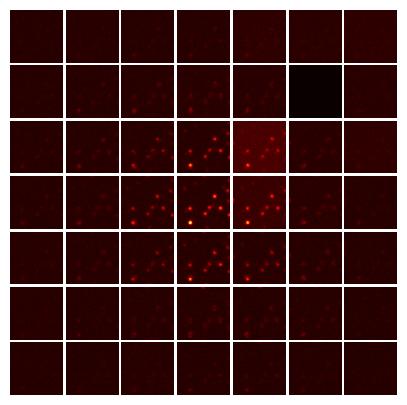

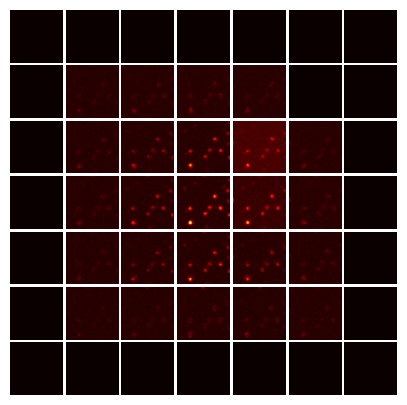

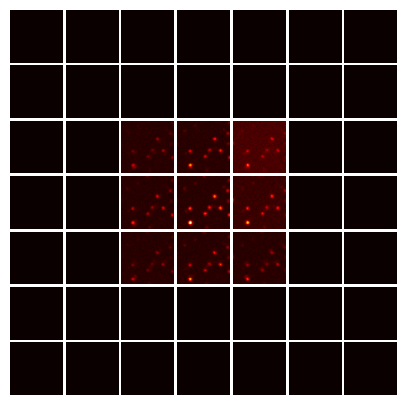

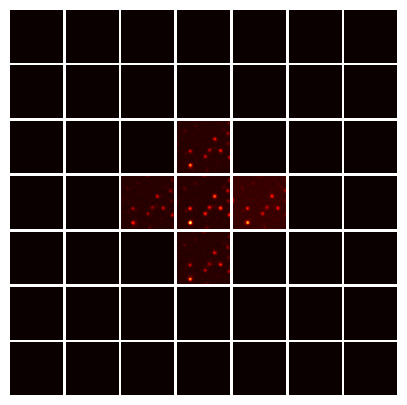

In [198]:
vmax = np.max(d7)
show_Dn(d7,vmax=vmax, vmin=0)
show_Dn(d5,vmax=vmax, vmin=0)
show_Dn(d3,vmax=vmax, vmin=0)
show_Dn(d1,vmax=vmax, vmin=0)

c:\Users\jocar\Desktop\tesi\.venv\Lib\site-packages\brighteyes_ism\analysis\Graph_lib.py:550: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



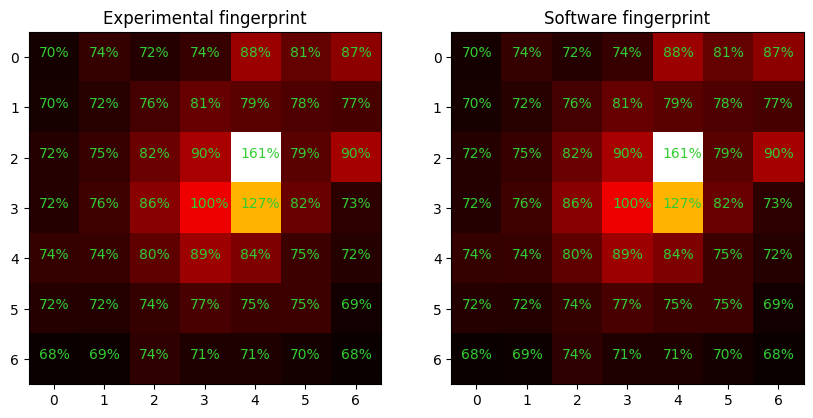

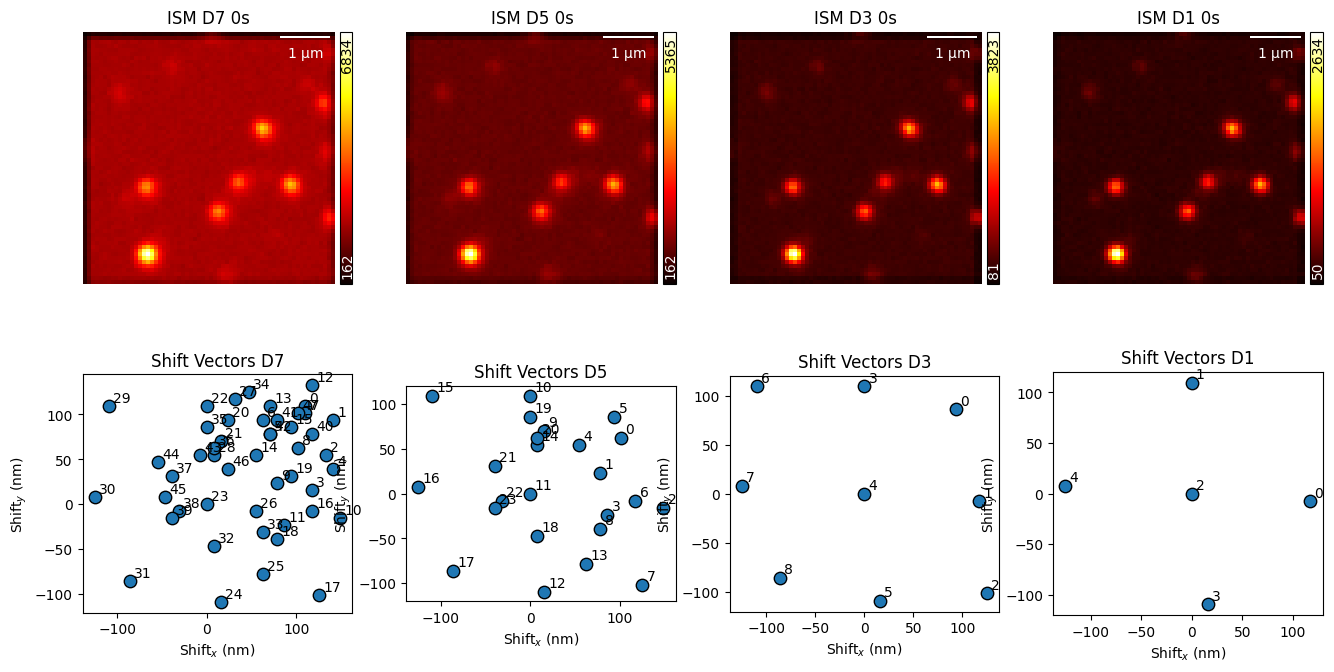

In [199]:
# RUN ISM
#############################################################################################
# CHECK FINGERPRINT
############################################################################################

fingerprint = tool.fingerprint(data.sum(axis=(0,1,4)))
fingerprint[1,5]=(fingerprint[1,4]+fingerprint[1,6])/2 #smooth D0 12
fingerprint_meta[1,5]=(fingerprint_meta[1,4]+fingerprint_meta[1,6])/2
c= int((D0Format-1)/2)  #change it if the maximum is not at the center

fig,ax= plt.subplots(1,2, figsize=(10,10))
ax[0].imshow(fingerprint, cmap='hot')
ax[1].imshow(fingerprint_meta, cmap='hot')

for i in range(7):
    for j in range(7):
        if str(round(fingerprint[i,j]*100/fingerprint[c,c])) != str(round(fingerprint_meta[i,j]*100/fingerprint_meta[c,c])):
            raise 'fingerprint not matching'
        ax[0].text(j-0.3,i, str(round(fingerprint[i,j]*100/fingerprint[c,c])) + '%', color='limegreen')
        ax[0].set_title('Experimental fingerprint')
        ax[1].text(j-0.3,i, str(round(fingerprint_meta[i,j]*100/fingerprint_meta[c,c])) + '%', color='limegreen')
        ax[1].set_title('Software fingerprint')

# fig_1 = gra.ShowDataset(np.sum(data,axis=(z_i,rep_i,t_i)),normalize = False, colorbar=False) # SHOW 49 images


#############################################################################################
# APR
############################################################################################

#ISM image
usf = 10  # upsampling factor = subpixel precision
ref_D5 = 11 # reference image to compute the shift vectors (center D0)
ref_D3 = 4  # reference image to compute the shift vectors (center D0)
ref_D7 = 23 # reference image to compute the shift vectors (center D0)
ref_D1 = 2 # reference image to compute the shift vectors (center D0)


start = time()
shift_vec7, ISM_D7_CH = apr.APR(d7, usf, ref_D7, filter_sigma=1, pxsize = pxsizex*1000) #pxsize in nm
ISM_D7 = ISM_D7_CH.sum(axis=2)
end = time()
TIME_ISM_D7 = end - start

start = time()
shift_vec5, ISM_D5_CH = apr.APR(d5, usf, ref_D5, filter_sigma=1, pxsize = pxsizex*1000) #pxsize in nm
ISM_D5 = ISM_D5_CH.sum(axis=2)
end = time()
TIME_ISM_D5 = end - start

start = time()
shift_vec3, ISM_D3_CH = apr.APR(d3, usf, ref_D3, filter_sigma=1, pxsize = pxsizex*1000)
ISM_D3 = ISM_D3_CH.sum(axis=2)
end = time()
TIME_ISM_D3 = end - start

start = time()
shift_vec1, ISM_D1_CH = apr.APR(d1, usf, ref_D1, filter_sigma=1, pxsize = pxsizex*1000)
ISM_D1 = ISM_D1_CH.sum(axis=2)
end = time()
TIME_ISM_D1 = end - start

fig, ax = plt.subplots(2, 4, figsize=(4*4,8))

gra.ShowImg(ISM_D7, pxsize_x = pxsizex, fig = fig, ax = ax[0,0], cmap='hot')
ax[0,0].set_title('ISM D7 ' + str(int(TIME_ISM_D7)) + 's')
gra.PlotShiftVectors(shift_vec7, fig = fig, ax = ax[1,0])
ax[1,0].set_title('Shift Vectors D7')

gra.ShowImg(ISM_D5, pxsize_x = pxsizex, fig = fig, ax = ax[0,1], cmap='hot')
ax[0,1].set_title('ISM D5 ' + str(int(TIME_ISM_D5)) + 's')
gra.PlotShiftVectors(shift_vec5, fig = fig, ax = ax[1,1])
ax[1,1].set_title('Shift Vectors D5')

gra.ShowImg(ISM_D3, pxsize_x = pxsizex, fig = fig, ax = ax[0,2], cmap='hot')
ax[0,2].set_title('ISM D3 ' + str(int(TIME_ISM_D3)) + 's')
gra.PlotShiftVectors(shift_vec3, fig = fig, ax = ax[1,2])
ax[1,2].set_title('Shift Vectors D3')

gra.ShowImg(ISM_D1, pxsize_x = pxsizex, fig = fig, ax = ax[0,3], cmap='hot')
ax[0,3].set_title('ISM D1 ' + str(int(TIME_ISM_D1)) + 's')
gra.PlotShiftVectors(shift_vec1, fig = fig, ax = ax[1,3])
ax[1,3].set_title('Shift Vectors D1')

plt.show()

# #############################################################################################
# # ISM VS D0
# ############################################################################################

# fig, ax = plt.subplots(1, 2, figsize=(15,10))

# gra.ShowImg(CENTRAL_D0[:,:], pxsize_x = pxsizex, fig = fig, ax = ax[0]) #[422:512,45:135]
# ax[0].set_title('Confocal central D0')

# gra.ShowImg(ISM_D5[:,:], pxsize_x = pxsizex, fig = fig, ax = ax[1]) #[320:356,206:242]
# ax[1].set_title('ISM D5')
# plt.show()

# del d1,d3,d5,d7
del ISM_D1_CH, ISM_D3_CH, ISM_D5_CH, ISM_D7_CH
# del shift_vec1, shift_vec3, shift_vec5, shift_vec7

In [200]:
# vmax=np.max(ISM_D7)
# vmin=0

# gra.ShowImg(CONFOCAL_D7, pxsize_x=pxsizex,vmax=vmax, vmin=vmin)
# plt.savefig('docs/images/ISM/conf_D7_3.png', dpi=300, bbox_inches='tight')
# plt.show()

In [201]:
# fig, ax = plt.subplots(figsize=(5, 5))
# im = ax.imshow(fingerprint, cmap='hot')
# for i in range(fingerprint.shape[0]):
#     for j in range(fingerprint.shape[1]):
#         ax.text(j, i, str(i * fingerprint.shape[1] + j)s, color='green', ha='center', va='center')
# # plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
# plt.axis('off')
# plt.show()

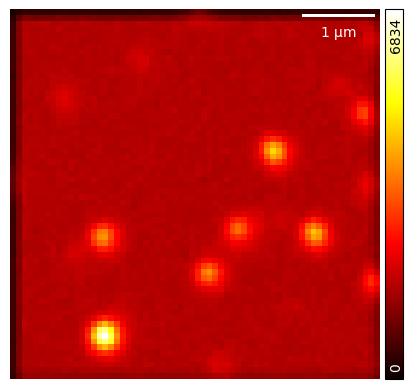

In [202]:
vmax = np.max(ISM_D7)
vmin = 0

gra.ShowImg(ISM_D7, pxsize_x = pxsizex, vmax=vmax, vmin=vmin, cmap='hot')
plt.savefig('docs/images/ISM/ISM_D7.png', dpi=300, bbox_inches='tight')
plt.show()

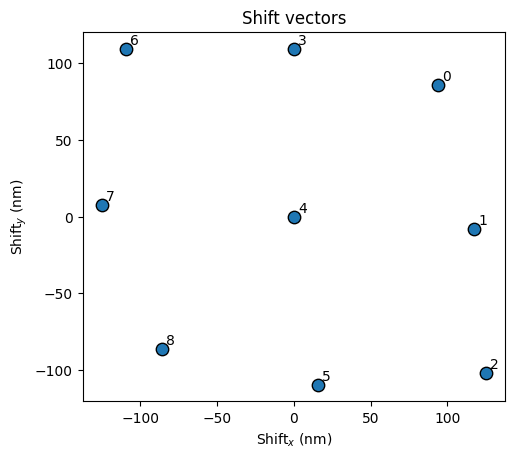

In [203]:
gra.PlotShiftVectors(shift_vec3)
plt.show()

# ANALYSIS

In [204]:
# IMAGES IN ISM_D1, ISM_D3, ISM_D5, ISM_D7
img_D0 = CENTRAL_D0 # /np.max(CENTRAL_D0) #img_sum#np.sum(data,axis=(0,1,4))[:,:,24]#img_deconv[-1,...] #insert here the images 1 and 2 that you want to analyse
img_D1 = ISM_D1 # /np.max(ISM_D1) #img_ism_sum#srrf_ism_1[...]
img_D3 = ISM_D3 #/np.max(ISM_D3) #img_ism_sum#srrf_ism_1[...]
img_D5 = ISM_D5 #/np.max(ISM_D5) #img_ism_sum#srrf_ism_1[...]
img_D7 = ISM_D7 #/np.max(ISM_D7) #img_ism_sum#srrf_ism_1[...]
sum_D1 = CONFOCAL_D1 #/np.max(D1) #img_ism_sum#srrf_ism_1[...]
sum_D3 = CONFOCAL_D3 #/np.max(D3) #img_ism_sum#srrf_ism_1[...]
sum_D5 = CONFOCAL_D5 #/np.max(D5) #img_ism_sum#srrf_ism_1[...]
sum_D7 = CONFOCAL_D7 #/np.max(D7) #img_ism_sum#srrf_ism_1[...

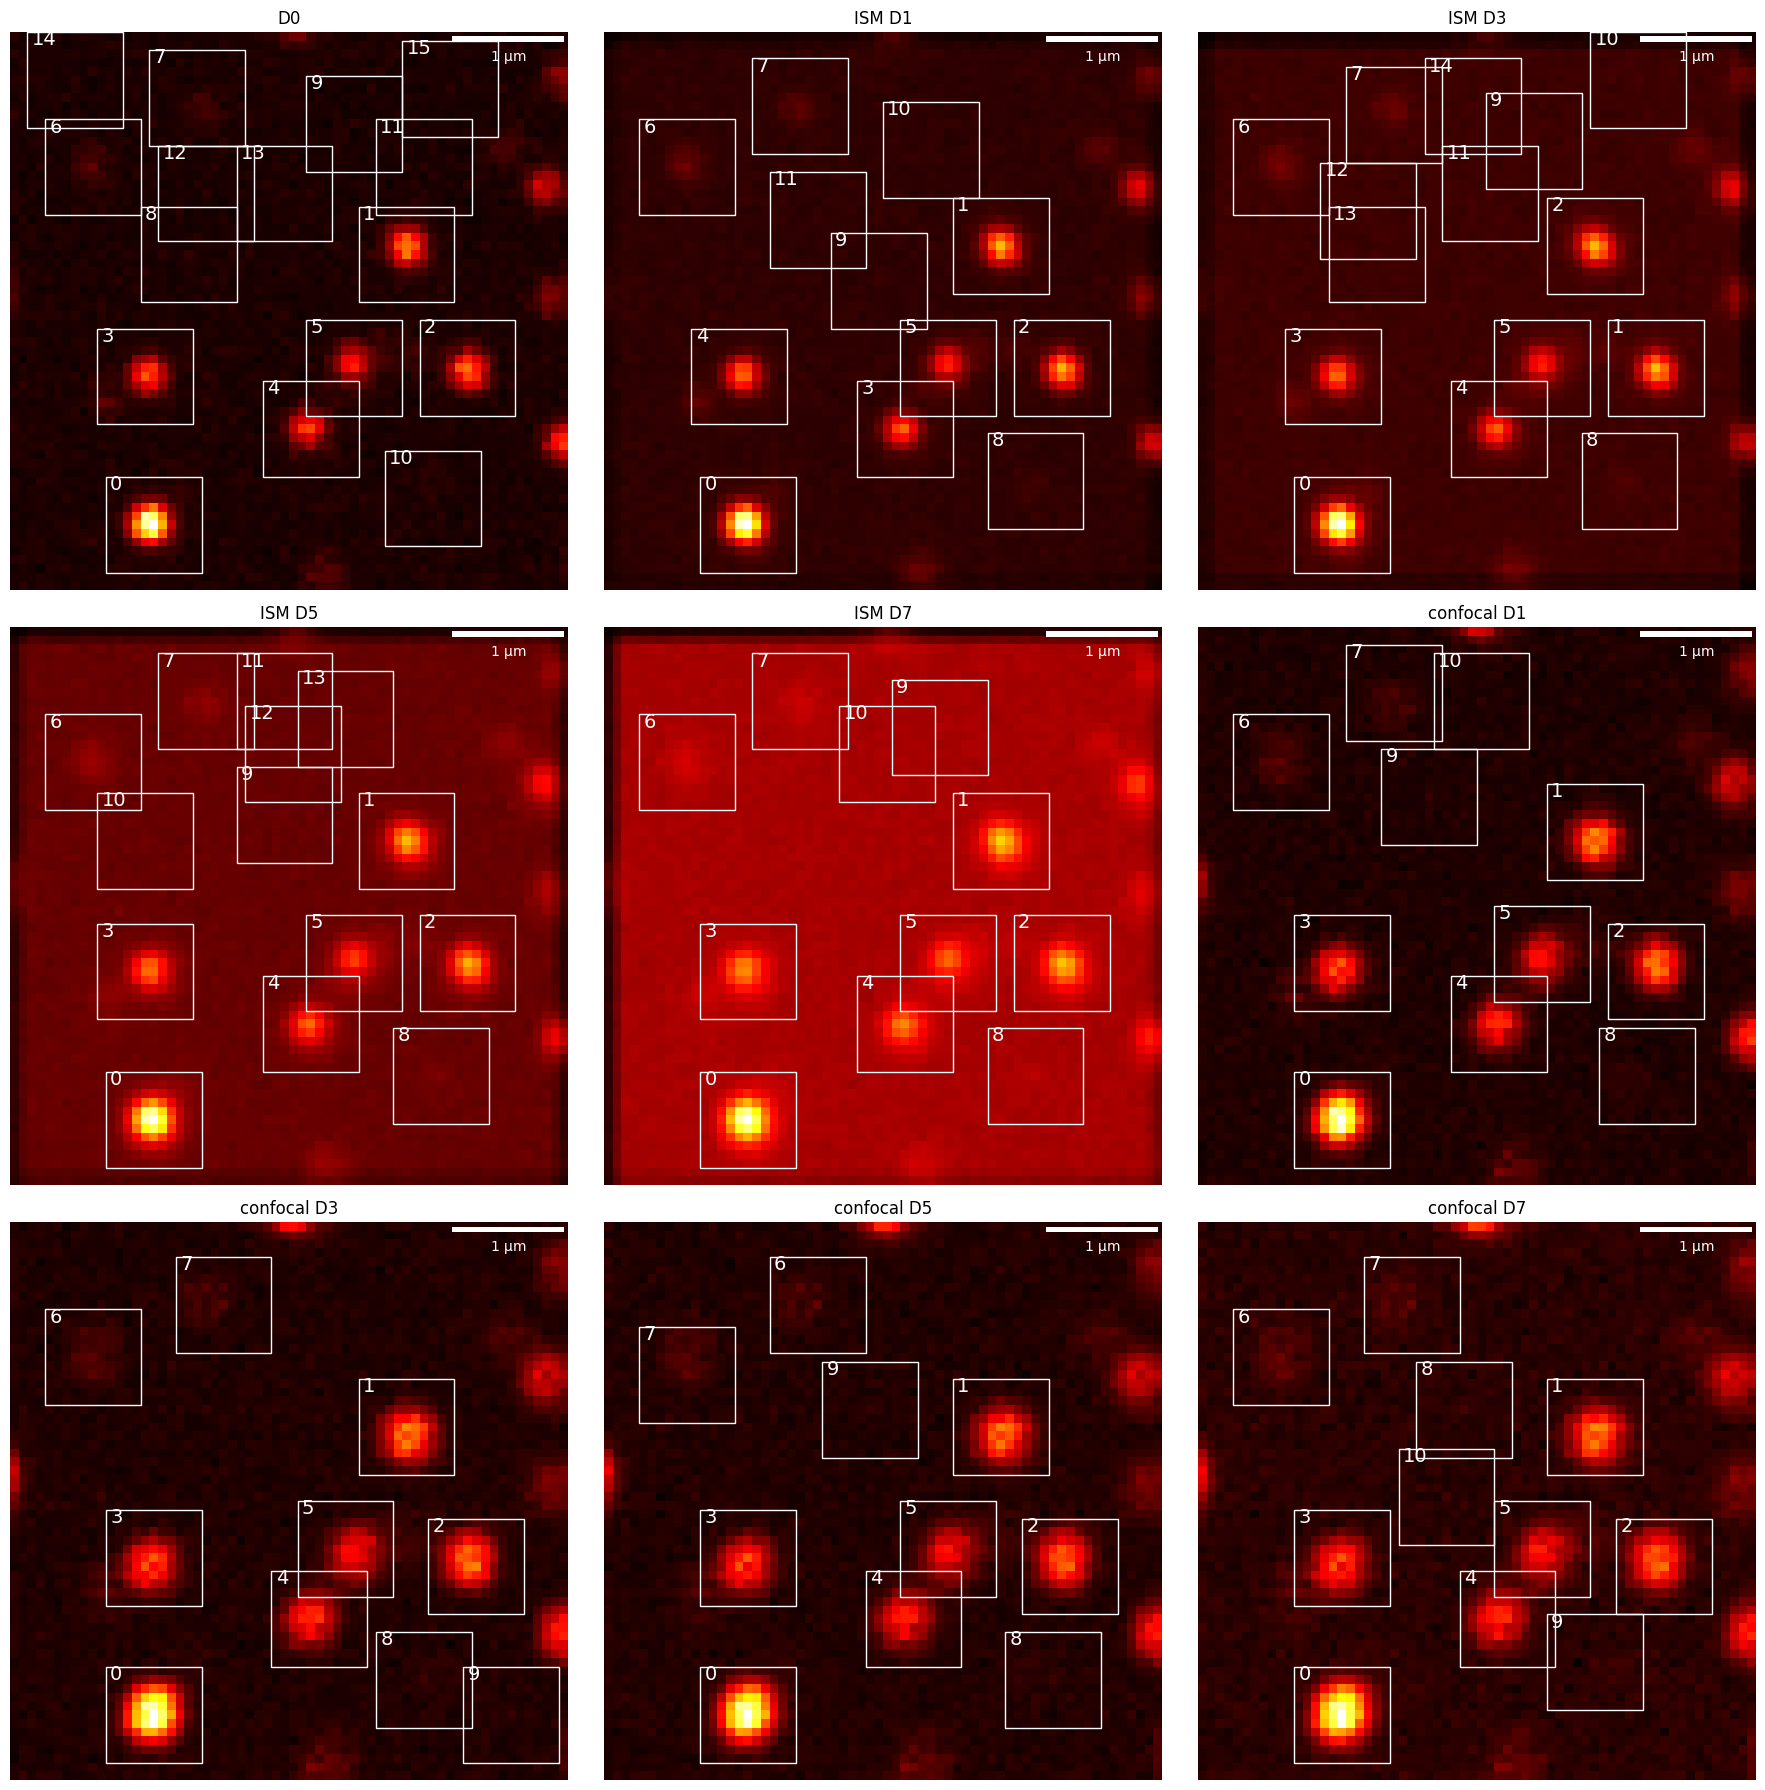

c:\Users\jocar\Desktop\tesi\images\2025 07 07-08 Qdots\Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2


In [205]:
# find peaks

ROIsizeC = 11 # size of the ROI box
radius = ROIsizeC//2
signal_thresh_D0 = np.mean(img_D0)
signal_thresh_D1 = np.mean(img_D1)
signal_thresh_D3 = np.mean(img_D3)
signal_thresh_D5 = np.mean(img_D5)
signal_thresh_D7 = np.mean(img_D7)
signal_thresh_sum_D1 = np.mean(sum_D1)
signal_thresh_sum_D3 = np.mean(sum_D3)
signal_thresh_sum_D5 = np.mean(sum_D5)
signal_thresh_sum_D7 = np.mean(sum_D7)

xc_D0=peak_local_max(img_D0,min_distance=radius, threshold_abs=signal_thresh_D0) # cordinates peaks
# maxvalues = np.array([img_D0[xc_D0[i,0],xc_D0[i,1]] for i in range(xc_D0.shape[0])])

xc_D1=peak_local_max(img_D1,min_distance=radius, threshold_abs=signal_thresh_D1) # cordinates peaks
# maxvalues = np.array([img_D1[xc_D1[i,0],xc_D1[i,1]] for i in range(xc_D1.shape[0])])

xc_D3=peak_local_max(img_D3,min_distance=radius, threshold_abs=signal_thresh_D3) # cordinates peaks
# maxvalues = np.array([img_D3[xc_D3[i,0],xc_D3[i,1]] for i in range(xc_D3.shape[0])])

xc_D5=peak_local_max(img_D5,min_distance=radius, threshold_abs=signal_thresh_D5) # cordinates peaks
# maxvalues = np.array([img_D5[xc_D5[i,0],xc_D5[i,1]] for i in range(xc_D5.shape[0])])

xc_D7=peak_local_max(img_D7,min_distance=radius, threshold_abs=signal_thresh_D7) # cordinates peaks
# maxvalues = np.array([img_D7[xc_D7[i,0],xc_D7[i,1]] for i in range(xc_D7.shape[0])])

xc_sum_D1=peak_local_max(sum_D1,min_distance=radius, threshold_abs=signal_thresh_sum_D1) # cordinates peaks
# maxvalues = np.array([sum_D1[xc_sum_D1[i,0],

xc_sum_D3=peak_local_max(sum_D3,min_distance=radius, threshold_abs=signal_thresh_sum_D3) # cordinates peaks
# maxvalues = np.array([sum_D3[xc_sum_D3[i,0],

xc_sum_D5=peak_local_max(sum_D5,min_distance=radius, threshold_abs=signal_thresh_sum_D5) # cordinates peaks
# maxvalues = np.array([sum_D5[xc_sum_D5[i,0],

xc_sum_D7=peak_local_max(sum_D7,min_distance=radius, threshold_abs=signal_thresh_sum_D7) # cordinates peaks
# maxvalues = np.array([sum_D7[xc_sum_D7[i,0],

# if xc_D0.shape != xc_D1.shape:
#     raise "xc_D1 != xc_D0 ha trovato più elementi in uno dei due"

Npart1 = xc_D0.shape[0]
Npart2 = xc_D1.shape[0]
Npart3 = xc_D3.shape[0]
Npart4 = xc_D5.shape[0]
Npart5 = xc_D7.shape[0]
Npart6 = xc_sum_D1.shape[0]
Npart7 = xc_sum_D3.shape[0]
Npart8 = xc_sum_D5.shape[0]
Npart9 = xc_sum_D7.shape[0]

fig, axes = plt.subplots(3, 3, figsize=(18, 18))

images = [img_D0, img_D1, img_D3, img_D5, img_D7, sum_D1, sum_D3, sum_D5, sum_D7]
coords = [xc_D0, xc_D1, xc_D3, xc_D5, xc_D7, xc_sum_D1, xc_sum_D3, xc_sum_D5, xc_sum_D7]
nparts = [Npart1, Npart2, Npart3, Npart4, Npart5, Npart6, Npart7, Npart8, Npart9]
titles = ['D0', 'ISM D1', 'ISM D3', 'ISM D5', 'ISM D7', 'confocal D1', 'confocal D3', 'confocal D5', 'confocal D7']

for i in range(9):
    ax = axes[i // 3, i % 3]
    #ax.imshow(images[i], cmap='hot')
    gra.ShowImg(images[i], pxsize_x = pxsizex, fig = fig, ax = ax, cmap='hot', colorbar=False)
    ax.set_title(titles[i])
    for l in range(nparts[i]):
        rect = Rectangle((coords[i][l,1]-ROIsizeC/2, coords[i][l,0]-ROIsizeC/2), ROIsizeC, ROIsizeC, linewidth=1, edgecolor='w', facecolor='none')
        ax.add_patch(rect)
        ax.text(coords[i][l,1]-radius, coords[i][l,0]-radius+1, l, fontsize=14, color='white')
plt.tight_layout()
plt.show()

print(filename)


In [206]:

# Initialize ROI_TO_ANALYSE based on the current file
if file == 'Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI3':
    ROI_TO_ANALYSE = {
        'ROI_D0': (0, 1, 5,),
        'ROI_D1':   (0, 1, 5),
        'ROI_D3':   (0, 1, 4),
        'ROI_D5':   (0, 1, 3),
        'ROI_D7':   (0, 1, 3),
        'ROI_sum_D1': (0, 1, 2),
        'ROI_sum_D3': (0, 1, 2,),
        'ROI_sum_D5': (0, 1, 2,),
        'ROI_sum_D7': (0, 1, 2,)
    }
elif file == 'Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_ROI8':
    ROI_TO_ANALYSE = {
        'ROI_D0': (0, 1, 2, 3, 4, 5, 6, 7),
        'ROI_D1':   (0, 2, 3, 4, 5, 7, 6, 8),
        'ROI_D3':   (0, 2, 3, 4, 5, 6, 7, 8),
        'ROI_D5':   (0, 2, 3, 4, 5, 6, 7, 8),
        'ROI_D7':   (0, 2, 3, 4, 5, 6, 7, 8),
        'ROI_sum_D1': (0, 1, 4, 3, 2, 5, 7, 6),
        'ROI_sum_D3': (0, 1, 3, 4, 2, 5, 7, 6),
        'ROI_sum_D5': (0, 1, 3, 4, 2, 5, 6, 7),
        'ROI_sum_D7': (0, 1, 3, 4, 2, 5, 6, 7)
    }
elif file == 'Qdots_770nm_34mW_FOV5um_64x64_30rip_5msPixel_ROI5':
    ROI_TO_ANALYSE = {
        'ROI_D0': (0, 1, 2, 4, 5, 3, 8),
        'ROI_D1':   (0, 2, 1, 4, 3, 5, 6),
        'ROI_D3':   (0, 2, 1, 4, 3, 5, 6),
        'ROI_D5':   (0, 1, 2, 4, 3, 5, 6),
        'ROI_D7':   (0, 1, 2, 3, 4, 6, 7),
        'ROI_sum_D1': (0, 2, 1, 4, 3, 5, 6),
        'ROI_sum_D3': (0, 2, 1, 4, 3, 5, 6),
        'ROI_sum_D5': (0, 1, 2, 4, 3, 5, 6),
        'ROI_sum_D7': (0, 1, 2, 4, 3, 5, 6)
    }
elif file == 'Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2':
    ROI_TO_ANALYSE = {
        'ROI_D0': (0, 1, 2, 3, 4, 5),
        'ROI_D1':   (0, 1, 2, 4, 3, 5),
        'ROI_D3':   (0, 2, 1, 3, 4, 5),
        'ROI_D5':   (0, 1, 2, 3, 4, 5),
        'ROI_D7':   (0, 1, 2, 3, 4, 5),
        'ROI_sum_D1': (0, 1, 2, 3, 4, 5),
        'ROI_sum_D3': (0, 1, 2, 3, 4, 5),
        'ROI_sum_D5': (0, 1, 2, 3, 4, 5),
        'ROI_sum_D7': (0, 1, 2, 3, 4, 5)
    }
elif file == 'Qdots_770nm_34mW_FOV5um_64x64_50rip_5msPixel_ROI4':
    ROI_TO_ANALYSE = {
        'ROI_D0': (0, 2, 5),
        'ROI_D1': (0, 2, 6),
        'ROI_D3': (0, 2, 5),
        'ROI_D5': (0, 2, 5),
        'ROI_D7': (0, 2, 6),
        'ROI_sum_D1': (0, 2, 5),
        'ROI_sum_D3': (0, 2, 6),
        'ROI_sum_D5': (0, 2, 4),
        'ROI_sum_D7': (0, 2, 4)
    }
elif file == 'Qdots_770nm_34mW_FOV3um_32x32_50rip_5msPixel_ROI7':
    ROI_TO_ANALYSE = {
        'ROI_D0': (0, 1),
        'ROI_D1': (0, 1),
        'ROI_D3': (0, 1),
        'ROI_D5': (0, 1),
        'ROI_D7': (0, 1)
    }
elif file == 'Qdots_770nm_34mW_FOV5um_64x64_60rip_2msPixel_ROI6':
    ROI_TO_ANALYSE = {
        'ROI_D0': (2, 8, 9, 10, 3),
        'ROI_D1': (1, 8, 6, 5, 3),
        'ROI_D3': (1, 8, 6, 5, 3),
        'ROI_D5': (1, 8, 5, 6, 3),
        'ROI_D7': (1, 8, 6, 5, 3)
    }
elif file == 'Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI3':
    ROI_TO_ANALYSE = {
        'ROI_D0': (2, 0, 1, 5),
        'ROI_D1':   (0, 1, 2, 5),
        'ROI_D3':   (0, 1, 2, 4),
        'ROI_D5':   (0, 1, 2, 3),
        'ROI_D7':   (0, 1, 2, 3)
    }
else:
    ROI_TO_ANALYSE = {}
# ROI_TO_ANALYSE = { # Qdots_770nm_34mW_FOV3um_32x32_50rip_5msPixel_ROI7
#     'ROI_D0': (0,3,4),
#     'ROI_D1': (0,2,3),
#     'ROI_D3': (0,1,2),
#     'ROI_D5': (0,1,2),
#     'ROI_D7': (0,1,2)
# }

# ROI_TO_ANALYSE = { # Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_ROI8
#     'ROI_D0': (0,1,2,3,4,5,6,7),
#     'ROI_D1':   (0,2,3,4,5,7,6,8),
#     'ROI_D3':   (0,2,3,4,5,6,7,8),
#     'ROI_D5':   (0,2,3,4,5,6,7,8),
#     'ROI_D7':   (0,2,3,4,5,6,7,8)
# }

# ROI_TO_ANALYSE = { # Qdots_770nm_34mW_FOV5um_64x64_30rip_5msPixel_ROI5
#     'ROI_D0': (0,1,2,4,5,3,8),
#     'ROI_D1':   (0,2,1,4,3,5,6),
#     'ROI_D3':   (0,2,1,4,3,5,6),
#     'ROI_D5':   (0,1,2,4,3,5,6),
#     'ROI_D7':   (0,1,2,3,4,6,7)
# }

# ROI_TO_ANALYSE = { # Qdots_770nm_34mW_FOV5um_64x64_50rip_5msPixel_ROI4
#     'ROI_D0': (0,2,5),
#     'ROI_D1': (0,2,6),
#     'ROI_D3': (0,2,5),
#     'ROI_D5': (0,2,5),
#     'ROI_D7': (0,2,6)
# }


# ROI_TO_ANALYSE = { # Qdots_770nm_34mW_FOV5um_64x64_60rip_2msPixel_ROI6
#     'ROI_D0': (2,8,9,10,3,),
#     'ROI_D1': (1,8,6,5,3,),
#     'ROI_D3': (1,8,6,5,3,),
#     'ROI_D5': (1,8,5,6,3,),
#     'ROI_D7': (1,8,6,5,3,)
# }

In [207]:
maxcolor = np.max(images)
mincolor = 0

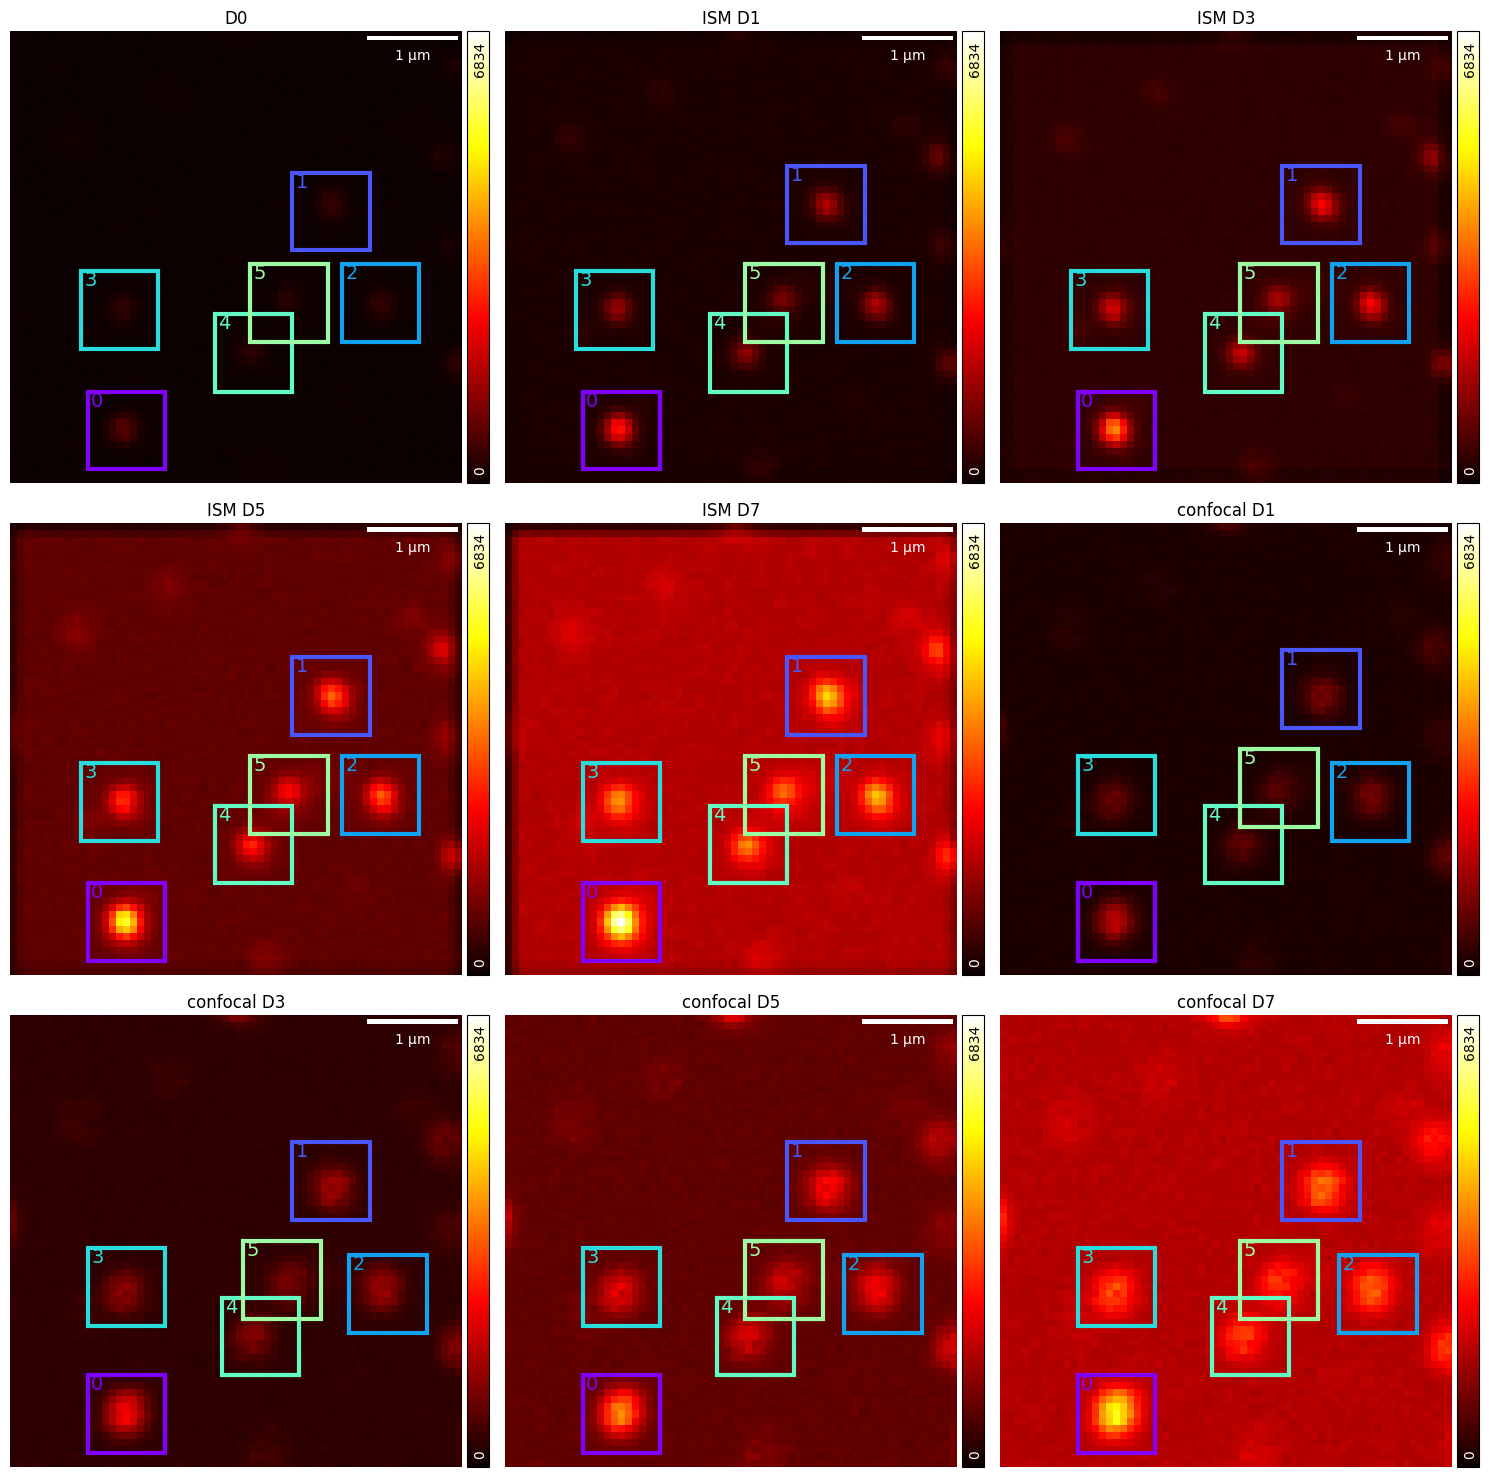

In [208]:
# from matplotlib.colors import CSS4_COLORS
from matplotlib import cm

# CHECK WITH COLORBOX

# List of 10 random colors from matplotlib's CSS4 color names
# Generate a gradient of 10 colors using a rainbow colormap

colors = [cm.rainbow(i / 9) for i in range(len(ROI_TO_ANALYSE['ROI_D0']))]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

images_key = ['ROI_D0', 'ROI_D1', 'ROI_D3', 'ROI_D5', 'ROI_D7', 'ROI_sum_D1', 'ROI_sum_D3', 'ROI_sum_D5', 'ROI_sum_D7']

for pos, im_key in enumerate(images_key):
    ax = axes[pos // 3, pos % 3]
    im = gra.ShowImg(images[pos], pxsize_x = pxsizex, fig = fig, ax = ax, cmap='hot', colorbar=True,vmin=mincolor, vmax=maxcolor) #[422:512,45:135]
    # im = ax.imshow(images[pos], cmap='hot', vmin=mincolor, vmax=maxcolor)
    ax.set_title(titles[pos])
    for l in range(len(ROI_TO_ANALYSE['ROI_D0'])):
        i = ROI_TO_ANALYSE[im_key][l]
        rect = Rectangle((coords[pos][i,1]-ROIsizeC/2, coords[pos][i,0]-ROIsizeC/2), ROIsizeC, ROIsizeC, linewidth=3, edgecolor=colors[l], facecolor='none')
        ax.add_patch(rect)
        ax.text(coords[pos][i,1]-radius, coords[pos][i,0]-radius+1.5, l, fontsize=14, color=colors[l])
    # fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [209]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# gra.ShowImg(img_D5, pxsize_x = pxsizex, fig = fig, ax = axes[0], cmap='hot', colorbar=False)
# axes[0].set_title('ISM D5')
# axes[0].axis('off')

# gra.ShowImg(sum_D5, pxsize_x = pxsizex, fig = fig, ax = axes[1], cmap='hot', colorbar=False)
# axes[1].set_title('confocal D5')
# axes[1].axis('off')

# plt.tight_layout()
# plt.show()

In [210]:
# def gaussian_radial_fit(coord, A, x0, y0, sigma, offset):
#     x, y = coord
#     r2 = (x - x0)**2 + (y - y0)**2
#     return A * np.exp(-r2 / (2 * sigma**2)) + offset

# R = 15 # dimensione ROI
# halfR = R//2 

# # seleziono la ROI 0 (centrata)
# y,x = xc_D5[2] 
# D5_roi = img_D5[y-halfR:y+halfR+1, x-halfR:x+halfR+1] # estraggo ROI da immagine ISM D5

# y,x = xc_sum_D5[2]
# # x = x-2 per testare ROI non centrata
# D5_sum_roi = sum_D5[y-halfR:y+halfR+1, x-halfR:x+halfR+1] # estraggo ROI da immagine confocale D5

# size = D5_roi.shape[1]

# x = np.arange(0, size)
# y = np.arange(0, size)
# X, Y = np.meshgrid(x, y)
# coord = (X.ravel(), Y.ravel())

# # plot ROIs
# fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# axs[0].imshow(D5_roi, cmap='hot')
# axs[0].set_title('ISM D5')
# axs[0].axis('off')
# axs[1].imshow(D5_sum_roi, cmap='hot')
# axs[1].set_title('Confocale D5')
# axs[1].axis('off')
# plt.tight_layout()
# plt.show()

# popt, pcov = curve_fit(gaussian_radial_fit, coord, D5_roi.ravel(), p0=[np.max(D5_roi), halfR, halfR, 3, np.min(D5_roi)]) # fit ISM
# popt2, pcov2 = curve_fit(gaussian_radial_fit, coord, D5_sum_roi.ravel(), p0=[np.max(D5_sum_roi), halfR, halfR, 3, np.min(D5_sum_roi)]) # fit confocale

# # Calculate sigma and error for ISM and Confocal fits, convert to nm, and round
# sigma_ism = popt[3] * pxsizex * 1000
# sigma_ism_err = np.sqrt(np.diag(pcov))[3] * pxsizex * 1000
# sigma_conf = popt2[3] * pxsizex * 1000
# sigma_conf_err = np.sqrt(np.diag(pcov2))[3] * pxsizex * 1000

# print(f'ISM Fit: {sigma_ism:.2f} ± {sigma_ism_err:.2f} nm')
# print(f'Confocal Fit: {sigma_conf:.2f} ± {sigma_conf_err:.2f} nm')
# guadagno = sigma_conf / sigma_ism
# guadagno_err = guadagno * np.sqrt((sigma_ism_err/sigma_ism)**2 + (sigma_conf_err/sigma_conf)**2)
# print(f'guadagno: {guadagno:.2f} ± {guadagno_err:.2f}')

In [211]:
# def gaussian_radial_fit(coord, A, x0, y0, sigma, offset):
#     x, y = coord
#     r2 = (x - x0)**2 + (y - y0)**2
#     return A * np.exp(-r2 / (2 * sigma**2)) + offset


# ISM_fit = []
# ISM_fit_err = []
# Confocal_fit_err = []
# Confocal_fit = []


# for R in range(8,16):
#     #R = 10 # dimensione ROI
#     halfR = R//2 

#     # seleziono la ROI 0 (centrata)
#     y,x = xc_D5[0] 
#     D5_roi = img_D5[y-halfR:y+halfR+1, x-halfR:x+halfR+1] # estraggo ROI da immagine ISM D5

#     y,x = xc_sum_D5[0]
#     # x = x-2 per testare ROI non centrata
#     D5_sum_roi = sum_D5[y-halfR:y+halfR+1, x-halfR:x+halfR+1] # estraggo ROI da immagine confocale D5

#     size = D5_roi.shape[0]

#     x = np.arange(0, size)
#     y = np.arange(0, size)
#     X, Y = np.meshgrid(x, y)
#     coord = (X.ravel(), Y.ravel())

#     # plot ROIs
#     # fig, axs = plt.subplots(1, 2, figsize=(10, 5))
#     # axs[0].imshow(D5_roi, cmap='hot')
#     # axs[0].set_title('ISM D5')
#     # axs[0].axis('off')
#     # axs[1].imshow(D5_sum_roi, cmap='hot')
#     # axs[1].set_title('Confocale D5')
#     # axs[1].axis('off')
#     # plt.tight_layout()
#     # plt.show()

#     popt, pcov = curve_fit(gaussian_radial_fit, coord, D5_roi.ravel(), p0=[np.max(D5_roi), halfR, halfR, 3, np.min(D5_roi)]) # fit ISM
#     popt2, pcov2 = curve_fit(gaussian_radial_fit, coord, D5_sum_roi.ravel(), p0=[np.max(D5_sum_roi), halfR, halfR, 3, np.min(D5_sum_roi)]) # fit confocale

#     # print('ISM Fit:', popt[3]*pxsizex*1000)
#     # print('Confocal Fit:', popt2[3]*pxsizex*1000)
#     # print('guadagno: ', np.round(popt2[3]/popt[3], 2))

#     ISM_fit.append(popt[3]*pxsizex*1000)
#     ISM_fit_err.append(np.sqrt(np.diag(pcov))[3]*pxsizex*1000)
#     Confocal_fit.append(popt2[3]*pxsizex*1000)
#     Confocal_fit_err.append(np.sqrt(np.diag(pcov2))[3]*pxsizex*1000)

In [212]:
# ISM_fit = np.array(ISM_fit)
# ISM_fit_err = np.array(ISM_fit_err)
# Confocal_fit = np.array(Confocal_fit)
# Confocal_fit_err = np.array(Confocal_fit_err)
# guadagno = Confocal_fit/ISM_fit
# guadagno_err = guadagno * np.sqrt((ISM_fit_err/ISM_fit)**2 + (Confocal_fit_err/Confocal_fit)**2)

# X = np.arange(8,22)

# fig, axs = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

# axs[0].errorbar(X, ISM_fit, yerr=ISM_fit_err, label='ISM Fit (sigma, nm)', marker='o', color='tab:blue', capsize=3)
# axs[0].set_ylabel('ISM Fit (sigma, nm)')
# axs[0].set_title('ISM Fit')
# axs[0].grid(True)
# axs[0].legend()

# axs[1].errorbar(X, Confocal_fit, yerr=Confocal_fit_err, label='Confocal Fit (sigma, nm)', marker='o', color='tab:orange', capsize=3)
# axs[1].set_ylabel('Confocal Fit (sigma, nm)')
# axs[1].set_title('Confocal Fit')
# axs[1].grid(True)
# axs[1].legend()

# axs[2].errorbar(X, guadagno, yerr=guadagno_err, label='Guadagno (Confocal/ISM)', marker='o', color='tab:green', capsize=3)
# axs[2].set_xlabel('R')
# axs[2].set_ylabel('Guadagno')
# axs[2].set_title('Guadagno (Confocal/ISM)')
# axs[2].grid(True)
# axs[2].legend()

# plt.tight_layout()
# plt.show()

In [213]:
# # Remove specific particles
# #Refresh the image above to see the updated indexes after every deletion!

# wh = img_1.shape[0] # image height and width
# halfsize = ROIsizeC / 2

# xc1 = xc2

# # remove elements from borders
# mask = (
#     ((xc1 + (halfsize, halfsize)) < wh).all(axis=1) &
#     ((xc1 - (halfsize, halfsize)) >= 0).all(axis=1)
# )

# xc1 = xc1[mask] # coordinate centrali dei box
# Npart = xc1.shape[0] # numero di box

# #[y,x]

In [214]:
try:
    ISM_DATAFRAME = pd.read_csv('./images/ISM/ISM_FWHM.csv')
except FileNotFoundError:
    ISM_DATAFRAME = pd.DataFrame(columns = ['FILE', 'D0', 'ISM D1', 'ISM D3', 'ISM D5', 'ISM D7', 'CONFOCALE D1', 'CONFOCALE D3', 'CONFOCALE D5', 'CONFOCALE D7', 'err D0', 'err ISM D1', 'err ISM D3', 'err ISM D5', 'err ISM D7', 'err CONFOCALE D1', 'err CONFOCALE D3', 'err CONFOCALE D5', 'err CONFOCALE D7', 'ROI D0', 'ROI ISM D1', 'ROI ISM D3', 'ROI ISM D5', 'ROI ISM D7', 'ROI CONFOCALE D1', 'ROI CONFOCALE D3', 'ROI CONFOCALE D5', 'ROI CONFOCALE D7'])

display(ISM_DATAFRAME)

,FILE,D0,ISM D1,ISM D3,ISM D5,ISM D7,CONFOCALE D1,CONFOCALE D3,CONFOCALE D5,CONFOCALE D7,...,err CONFOCALE D7,ROI D0,ROI ISM D1,ROI ISM D3,ROI ISM D5,ROI ISM D7,ROI CONFOCALE D1,ROI CONFOCALE D3,ROI CONFOCALE D5,ROI CONFOCALE D7
0,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,266.0,270.0,280.0,313.0,323.0,345.0,379.0,387.0,396.0,...,3.0,0,0,0,0,0,0,0,0,0
1,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,272.0,265.0,271.0,305.0,313.0,344.0,379.0,390.0,396.0,...,5.0,1,1,2,1,1,1,1,1,1
2,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,273.0,260.0,262.0,295.0,306.0,341.0,375.0,386.0,397.0,...,6.0,2,2,1,2,2,2,2,2,2
3,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,260.0,254.0,261.0,296.0,311.0,339.0,372.0,386.0,398.0,...,7.0,3,4,3,3,3,3,3,3,3
4,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,246.0,237.0,243.0,271.0,280.0,308.0,335.0,348.0,353.0,...,20.0,4,3,4,4,4,4,4,4,4
5,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,241.0,248.0,254.0,274.0,281.0,326.0,358.0,356.0,362.0,...,23.0,5,5,5,5,5,5,5,5,5
6,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI3,227.0,231.0,247.0,260.0,270.0,284.0,304.0,301.0,311.0,...,5.0,0,0,0,0,0,0,0,0,0
7,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI3,217.0,222.0,241.0,262.0,270.0,282.0,302.0,304.0,310.0,...,14.0,1,1,1,1,1,1,1,1,1
8,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI3,278.0,294.0,310.0,326.0,339.0,339.0,363.0,362.0,375.0,...,10.0,5,5,4,3,3,2,2,2,2


In [215]:
def gaussian_radial_fit(coord, A, x0, y0, sigma, offset):
    x, y = coord
    r2 = (x - x0)**2 + (y - y0)**2
    return A * np.exp(-r2 / (2 * sigma**2)) + offset

# popt, pcov = curve_fit(gaussian_radial_fit, coord, D5_roi.ravel(), p0=[np.max(D5_roi), halfR, halfR, 3, np.min(D5_roi)]) # fit ISM
# popt2, pcov2 = curve_fit(gaussian_radial_fit, coord, D5_sum_roi.ravel(), p0=[np.max(D5_sum_roi), halfR, halfR, 3, np.min(D5_sum_roi)]) # fit confocale
ROIsizeC = 15
Δ = ROIsizeC // 2

#ISM_DATAFRAME = pd.DataFrame() # pd.read_csv('./images/ISM/ISM_FWHM.csv')

result = []

for i in range(len(ROI_TO_ANALYSE['ROI_D0'])):

    y,x = xc_D0[ROI_TO_ANALYSE['ROI_D0'][i]]
    index_ROI_CENTRAL_D0 = ROI_TO_ANALYSE['ROI_D0'][i]
    ROI_D0 = img_D0[y-Δ:y+Δ+1, x-Δ:x+Δ+1]
    
    size = ROI_D0.shape[0]

    y,x = xc_D1[ROI_TO_ANALYSE['ROI_D1'][i]]
    index_ROI_CENTRAL_D1 = ROI_TO_ANALYSE['ROI_D1'][i]
    ROI_D1 = img_D1[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    y,x = xc_D3[ROI_TO_ANALYSE['ROI_D3'][i]]
    index_ROI_CENTRAL_D3 = ROI_TO_ANALYSE['ROI_D3'][i]
    ROI_D3 = img_D3[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    y,x = xc_D5[ROI_TO_ANALYSE['ROI_D5'][i]]
    index_ROI_CENTRAL_D5 = ROI_TO_ANALYSE['ROI_D5'][i]
    ROI_D5 = img_D5[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    y,x = xc_D7[ROI_TO_ANALYSE['ROI_D7'][i]]
    index_ROI_CENTRAL_D7 = ROI_TO_ANALYSE['ROI_D7'][i]
    ROI_D7 = img_D7[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    y,x = xc_sum_D1[ROI_TO_ANALYSE['ROI_sum_D1'][i]]
    index_ROI_CENTRAL_sum_D1 = ROI_TO_ANALYSE['ROI_sum_D1'][i]
    ROI_sum_D1 = sum_D1[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    y,x = xc_sum_D3[ROI_TO_ANALYSE['ROI_sum_D3'][i]]
    index_ROI_CENTRAL_sum_D3 = ROI_TO_ANALYSE['ROI_sum_D3'][i]
    ROI_sum_D3 = sum_D3[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    y,x = xc_sum_D5[ROI_TO_ANALYSE['ROI_sum_D5'][i]]
    index_ROI_CENTRAL_sum_D5 = ROI_TO_ANALYSE['ROI_sum_D5'][i]
    ROI_sum_D5 = sum_D5[y-Δ:y+Δ+1, x-Δ:x+Δ+1]
    
    y,x = xc_sum_D7[ROI_TO_ANALYSE['ROI_sum_D7'][i]]
    index_ROI_CENTRAL_sum_D7 = ROI_TO_ANALYSE['ROI_sum_D7'][i]
    ROI_sum_D7 = sum_D7[y-Δ:y+Δ+1, x-Δ:x+Δ+1]


    # fig, axs = plt.subplots(3, 3, figsize=(12, 12))
    # rois = [
    #     (ROI_D0, 'D0'),
    #     (ROI_D1, 'ISM D1'),
    #     (ROI_D3, 'ISM D3'),
    #     (ROI_D5, 'ISM D5'),
    #     (ROI_D7, 'ISM D7'),
    #     (ROI_sum_D1, 'CONFOCALE D1'),
    #     (ROI_sum_D3, 'CONFOCALE D3'),
    #     (ROI_sum_D5, 'CONFOCALE D5'),
    #     (ROI_sum_D7, 'CONFOCALE D7')
    # ]

    # for ax, (roi, title) in zip(axs.ravel(), rois):
    #     im = ax.imshow(roi, cmap='hot')
    #     ax.set_title(title)
    #     ax.axis('off')
    #     fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # plt.tight_layout()
    # plt.show()

    # break

    x = np.arange(0, size)
    y = np.arange(0, size)
    X, Y = np.meshgrid(x, y)
    coord = (X.ravel(), Y.ravel())

    limits = ([0, 0, 0, -np.inf], [np.inf, size, np.inf, np.inf])

    # Fit D0
    popt_D0, pcov_D0 = curve_fit(gaussian_radial_fit, coord, ROI_D0.ravel(),p0=[np.max(ROI_D0), size/2, size/2, 3, np.mean(ROI_D0)])
    FWHM_D0 = np.round(2.355 * popt_D0[3] * pxsizex * 1000, 0)
    sigma_FWHM_D0 = np.round(2.355 * np.sqrt(np.diag(pcov_D0))[3] * pxsizex * 1000, 0)

    # Fit D1
    popt_D1, pcov_D1 = curve_fit(gaussian_radial_fit, coord, ROI_D1.ravel(),p0=[np.max(ROI_D1), size/2, size/2, 3, np.mean(ROI_D1)])
    FWHM_D1 = np.round(2.355 * popt_D1[3] * pxsizex * 1000, 0)
    sigma_FWHM_D1 = np.round(2.355 * np.sqrt(np.diag(pcov_D1))[3] * pxsizex * 1000, 0)

    # Fit D3
    popt_D3, pcov_D3 = curve_fit(gaussian_radial_fit, coord, ROI_D3.ravel(),p0=[np.max(ROI_D3), size/2, size/2, 3, np.mean(ROI_D3)])
    FWHM_D3 = np.round(2.355 * popt_D3[3] * pxsizex * 1000, 0)
    sigma_FWHM_D3 = np.round(2.355 * np.sqrt(np.diag(pcov_D3))[3] * pxsizex * 1000, 0)

    # Fit D5
    popt_D5, pcov_D5 = curve_fit(gaussian_radial_fit, coord, ROI_D5.ravel(),p0=[np.max(ROI_D5), size/2, size/2, 3, np.mean(ROI_D5)])
    FWHM_D5 = np.round(2.355 * popt_D5[3] * pxsizex * 1000, 0)
    sigma_FWHM_D5 = np.round(2.355 * np.sqrt(np.diag(pcov_D5))[3] * pxsizex * 1000, 0)

    # Fit D7
    popt_D7, pcov_D7 = curve_fit(gaussian_radial_fit, coord, ROI_D7.ravel(),p0=[np.max(ROI_D7), size/2, size/2, 3, np.mean(ROI_D7)])
    FWHM_D7 = np.round(2.355 * popt_D7[3] * pxsizex * 1000, 0)
    sigma_FWHM_D7 = np.round(2.355 * np.sqrt(np.diag(pcov_D7))[3] * pxsizex * 1000, 0)

    # Fit sum_D1
    popt_sum_D1, pcov_sum_D1 = curve_fit(gaussian_radial_fit, coord, ROI_sum_D1.ravel(),p0=[np.max(ROI_sum_D1), size/2, size/2, 3, np.mean(ROI_sum_D1)])
    FWHM_sum_D1 = np.round(2.355 * popt_sum_D1[3] * pxsizex * 1000, 0)
    sigma_FWHM_sum_D1 = np.round(2.355 * np.sqrt(np.diag(pcov_sum_D1))[3] * pxsizex * 1000, 0)

    # Fit sum_D3
    popt_sum_D3, pcov_sum_D3 = curve_fit(gaussian_radial_fit, coord, ROI_sum_D3.ravel(),p0=[np.max(ROI_sum_D3), size/2, size/2, 3, np.mean(ROI_sum_D3)])
    FWHM_sum_D3 = np.round(2.355 * popt_sum_D3[3] * pxsizex * 1000, 0)
    sigma_FWHM_sum_D3 = np.round(2.355 * np.sqrt(np.diag(pcov_sum_D3))[3] * pxsizex * 1000, 0)

    # Fit sum_D5
    popt_sum_D5, pcov_sum_D5 = curve_fit(gaussian_radial_fit, coord, ROI_sum_D5.ravel(),p0=[np.max(ROI_sum_D5), size/2, size/2, 3, np.mean(ROI_sum_D5)])
    FWHM_sum_D5 = np.round(2.355 * popt_sum_D5[3] * pxsizex * 1000, 0)
    sigma_FWHM_sum_D5 = np.round(2.355 * np.sqrt(np.diag(pcov_sum_D5))[3] * pxsizex * 1000, 0)

    # Fit sum_D7
    popt_sum_D7, pcov_sum_D7 = curve_fit(gaussian_radial_fit, coord, ROI_sum_D7.ravel(),p0=[np.max(ROI_sum_D7), size/2, size/2, 3, np.mean(ROI_sum_D7)])
    FWHM_sum_D7 = np.round(2.355 * popt_sum_D7[3] * pxsizex * 1000, 0)
    sigma_FWHM_sum_D7 = np.round(2.355 * np.sqrt(np.diag(pcov_sum_D7))[3] * pxsizex * 1000, 0)

    FWHM_values = {
        'FILE': file,
        
        'D0': int(FWHM_D0),
        'ISM D1': int(FWHM_D1),
        'ISM D3': int(FWHM_D3),
        'ISM D5': int(FWHM_D5),
        'ISM D7': int(FWHM_D7),
        'CONFOCALE D1': int(FWHM_sum_D1),
        'CONFOCALE D3': int(FWHM_sum_D3),
        'CONFOCALE D5': int(FWHM_sum_D5),
        'CONFOCALE D7': int(FWHM_sum_D7),

        'err D0': int(sigma_FWHM_D0),
        'err ISM D1': int(sigma_FWHM_D1),
        'err ISM D3': int(sigma_FWHM_D3),
        'err ISM D5': int(sigma_FWHM_D5),
        'err ISM D7': int(sigma_FWHM_D7),
        'err CONFOCALE D1': int(sigma_FWHM_sum_D1),
        'err CONFOCALE D3': int(sigma_FWHM_sum_D3),
        'err CONFOCALE D5': int(sigma_FWHM_sum_D5),
        'err CONFOCALE D7': int(sigma_FWHM_sum_D7),
    
        'ROI D0': int(index_ROI_CENTRAL_D0),
        'ROI ISM D1': int(index_ROI_CENTRAL_D1),
        'ROI ISM D3': int(index_ROI_CENTRAL_D3),
        'ROI ISM D5': int(index_ROI_CENTRAL_D5),
        'ROI ISM D7': int(index_ROI_CENTRAL_D7),
        'ROI CONFOCALE D1': int(index_ROI_CENTRAL_sum_D1),
        'ROI CONFOCALE D3': int(index_ROI_CENTRAL_sum_D3),
        'ROI CONFOCALE D5': int(index_ROI_CENTRAL_sum_D5),
        'ROI CONFOCALE D7': int(index_ROI_CENTRAL_sum_D7)
    }

    # print(f'D0:   {int(round(FWHM_D0))} ± {int(round(sigma_FWHM_D0))} nm   ({np.round(sigma_FWHM_D0/FWHM_D0*100,2)} %)')
    # print(f'ISM_D1:         {int(round(FWHM_D1))} ± {int(round(sigma_FWHM_D1))} nm   ({np.round(sigma_FWHM_D1/FWHM_D1*100,2)} %)')
    # print(f'ISM_D3:         {int(round(FWHM_D3))} ± {int(round(sigma_FWHM_D3))} nm   ({np.round(sigma_FWHM_D3/FWHM_D3*100,2)} %)')
    # print(f'ISM_D5:         {int(round(FWHM_D5))} ± {int(round(sigma_FWHM_D5))} nm   ({np.round(sigma_FWHM_D5/FWHM_D5*100,2)} %)')
    # print(f'ISM_D7:         {int(round(FWHM_D7))} ± {int(round(sigma_FWHM_D7))} nm   ({np.round(sigma_FWHM_D7/FWHM_D7*100,2)} %)')
    # print(f'confocal_D1:     {int(round(FWHM_sum_D1))} ± {int(round(sigma_FWHM_sum_D1))} nm   ({np.round(sigma_FWHM_sum_D1/FWHM_sum_D1*100,2)} %)')
    # print(f'confocal_D3:     {int(round(FWHM_sum_D3))} ± {int(round(sigma_FWHM_sum_D3))} nm   ({np.round(sigma_FWHM_sum_D3/FWHM_sum_D3*100,2)} %)')
    # print(f'confocal_D5:     {int(round(FWHM_sum_D5))} ± {int(round(sigma_FWHM_sum_D5))} nm   ({np.round(sigma_FWHM_sum_D5/FWHM_sum_D5*100,2)} %)')
    # print(f'confocal_D7:     {int(round(FWHM_sum_D7))} ± {int(round(sigma_FWHM_sum_D7))} nm   ({np.round(sigma_FWHM_sum_D7/FWHM_sum_D7*100,2)} %)')
    # print('-----------------------------------')

    result.append(FWHM_values)
    # D0, ISM D1, ISM D3, ISM D5, ISM D7, CONFOCALE D1, sum ISM_D3, sum ISM_D5, sum ISM_D7, err CENTAL D0, err ISM_D1, err ISM_D3, err ISM_D5, err ISM_D7, err sum ISM_D1, err sum ISM_D3, err sum ISM_D5, err sum_ISM_D7, FILE, ROI CENTRAL D0, ROI ISM_D1, ROI ISM_D3, ROI ISM_D5, ROI ISM_D7, ROI sum ISM_D1, ROI sum ISM_D3, ROI sum ISM_D5, ROI sum ISM_D7

    ISM_DATAFRAME = pd.concat([ISM_DATAFRAME, pd.DataFrame([FWHM_values])],ignore_index=True)
    #ISM_DATAFRAME.loc[len(ISM_DATAFRAME)] = pd.Series(FWHM_values)

display(pd.DataFrame(result))

# ISM_DATAFRAME.to_csv('./images/ISM/ISM_FWHM.csv', index=False)


,FILE,D0,ISM D1,ISM D3,ISM D5,ISM D7,CONFOCALE D1,CONFOCALE D3,CONFOCALE D5,CONFOCALE D7,...,err CONFOCALE D7,ROI D0,ROI ISM D1,ROI ISM D3,ROI ISM D5,ROI ISM D7,ROI CONFOCALE D1,ROI CONFOCALE D3,ROI CONFOCALE D5,ROI CONFOCALE D7
0,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,266,270,280,313,323,345,379,387,396,...,3,0,0,0,0,0,0,0,0,0
1,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,272,265,271,305,313,344,379,390,396,...,5,1,1,2,1,1,1,1,1,1
2,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,273,260,262,295,306,341,375,386,397,...,6,2,2,1,2,2,2,2,2,2
3,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,260,254,261,296,311,339,372,386,398,...,7,3,4,3,3,3,3,3,3,3
4,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,246,237,243,271,280,308,335,348,353,...,20,4,3,4,4,4,4,4,4,4
5,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,241,248,254,274,281,326,358,356,362,...,23,5,5,5,5,5,5,5,5,5


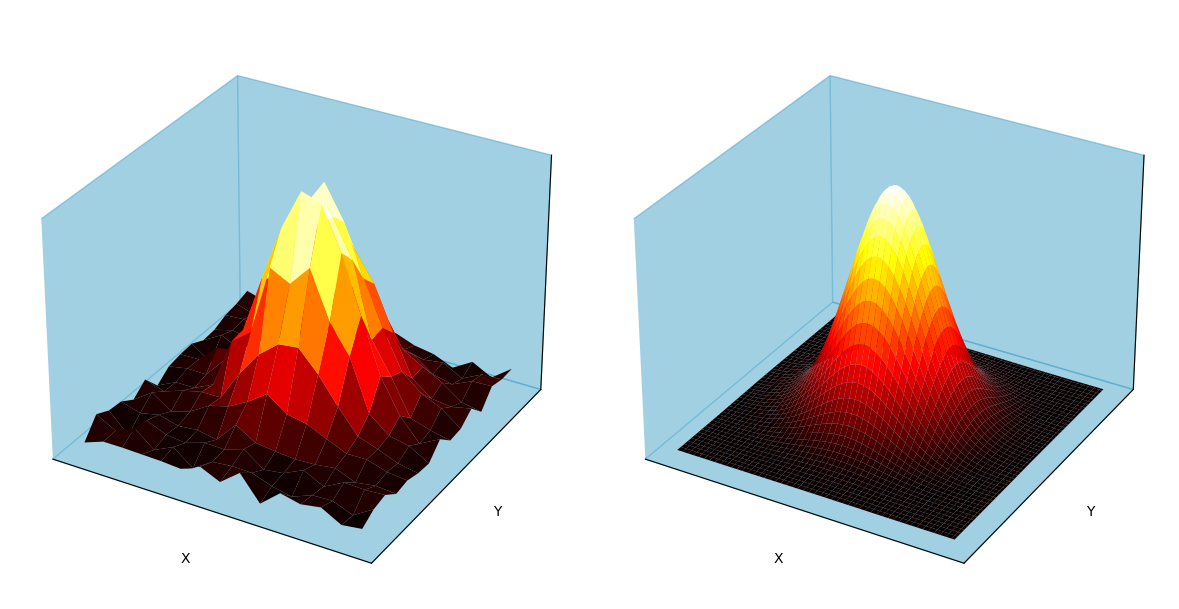

In [216]:
from mpl_toolkits.mplot3d import Axes3D

def gaussian_radial_fit(coord, A, x0, y0, sigma, offset):
    x, y = coord
    r2 = (x - x0)**2 + (y - y0)**2
    return A * np.exp(-r2 / (2 * sigma**2)) + offset

# popt, pcov = curve_fit(gaussian_radial_fit, coord, D5_roi.ravel(), p0=[np.max(D5_roi), halfR, halfR, 3, np.min(D5_roi)]) # fit ISM
# popt2, pcov2 = curve_fit(gaussian_radial_fit, coord, D5_sum_roi.ravel(), p0=[np.max(D5_sum_roi), halfR, halfR, 3, np.min(D5_sum_roi)]) # fit confocale
ROIsizeC = 15
Δ = ROIsizeC // 2

#ISM_DATAFRAME = pd.DataFrame() # pd.read_csv('./images/ISM/ISM_FWHM.csv')

i = 1
y,x = xc_sum_D7[ROI_TO_ANALYSE['ROI_sum_D7'][i]]
index_ROI_CENTRAL_sum_D7 = ROI_TO_ANALYSE['ROI_sum_D7'][i]
ROI_sum_D7 = sum_D7[y-Δ:y+Δ+1, x-Δ:x+Δ+1]
size = ROI_sum_D7.shape[0]

x = np.arange(0, size)
y = np.arange(0, size)
X, Y = np.meshgrid(x, y)
coord = (X.ravel(), Y.ravel())

limits = ([0, 0, 0, -np.inf], [np.inf, size, np.inf, np.inf])

popt_sum_D7, pcov_sum_D7 = curve_fit(gaussian_radial_fit, coord, ROI_sum_D7.ravel(),p0=[np.max(ROI_sum_D7), size/2, size/2, 3, np.mean(ROI_sum_D7)])
FWHM_sum_D7 = np.round(2.355 * popt_sum_D7[3] * pxsizex * 1000, 0)
sigma_FWHM_sum_D7 = np.round(2.355 * np.sqrt(np.diag(pcov_sum_D7))[3] * pxsizex * 1000, 0)


# plt.imshow(ROI_sum_D7, cmap='hot')
# plt.axis('off')
# plt.show()
# Set background color for both 3D plots
fig = plt.figure(figsize=(12, 6))
# First subplot: 3D surface of ROI_sum_D7 data
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
X_data, Y_data = np.meshgrid(np.arange(size), np.arange(size))
Z_data = ROI_sum_D7
ax1.plot_surface(X_data, Y_data, Z_data, cmap='hot', edgecolor='none')
ax1.set_title('ROI_sum_D7 3D Surface', color='white')
ax1.set_xlabel('X', color='black')
ax1.set_ylabel('Y', color='black')
ax1.set_zlabel('Intensity', color='white')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_zticks([])
ax1.grid(True, color='white')  # Set grid color to blue
ax1.xaxis.set_pane_color("#46A3C8",alpha=0.5)
ax1.yaxis.set_pane_color("#46A3C8",alpha=0.5)
ax1.zaxis.set_pane_color("#46A3C8",alpha=0.5)

# Second subplot: 3D surface of fitted Gaussian
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
A, x0, y0, sigma, offset = popt_sum_D7
X_fit, Y_fit = np.meshgrid(np.linspace(0, size, 100), np.linspace(0, size, 100))
fit_surface = gaussian_radial_fit((X_fit, Y_fit), A, x0, y0, sigma, offset)
ax2.plot_surface(X_fit, Y_fit, fit_surface.reshape(X_fit.shape), cmap='hot', edgecolor='none')
ax2.set_title('Fitted 2D Gaussian Surface', color='white')
ax2.set_xlabel('X', color="black")
ax2.set_ylabel('Y', color='black')
ax2.set_zlabel('Intensity', color='black')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_zticks([])
ax2.grid(True, color='white')  # Set grid color to blue
ax2.xaxis.set_pane_color("#46A3C8",alpha=0.5)
ax2.yaxis.set_pane_color("#46A3C8",alpha=0.5)
ax2.zaxis.set_pane_color("#46A3C8",alpha=0.5)
plt.tight_layout()
plt.show()


In [217]:
# print(FWHM_values.keys())

In [218]:
# display(ISM_DATAFRAME)

In [219]:
# ISM_DATAFRAME.to_csv('./images/ISM/ISM_FWHM.csv', index=False)

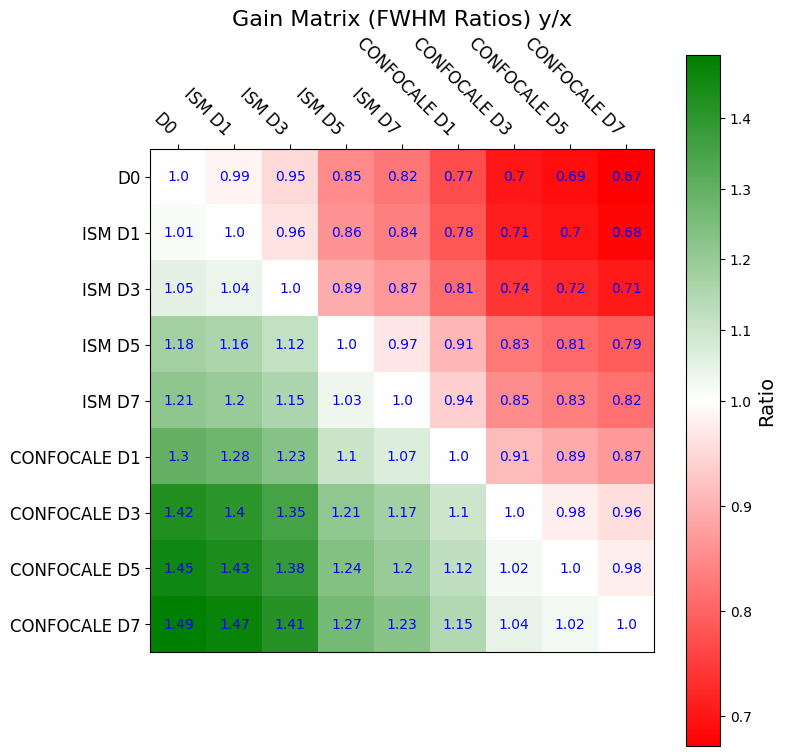

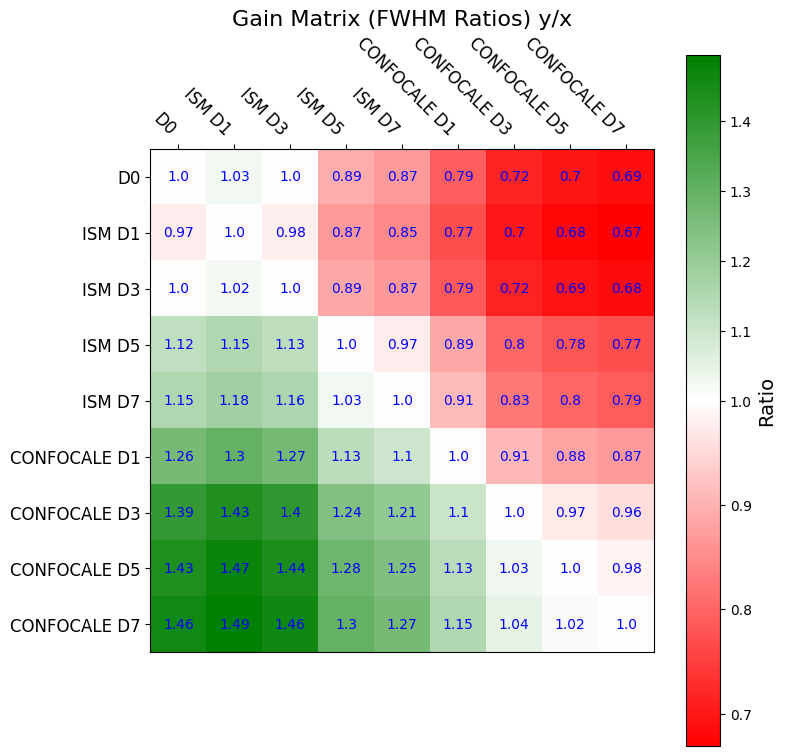

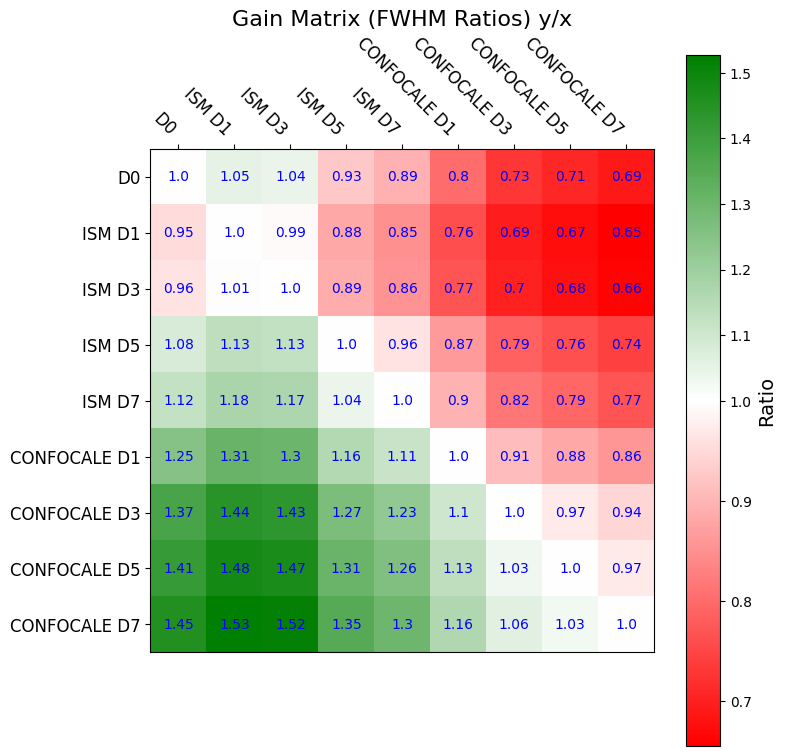

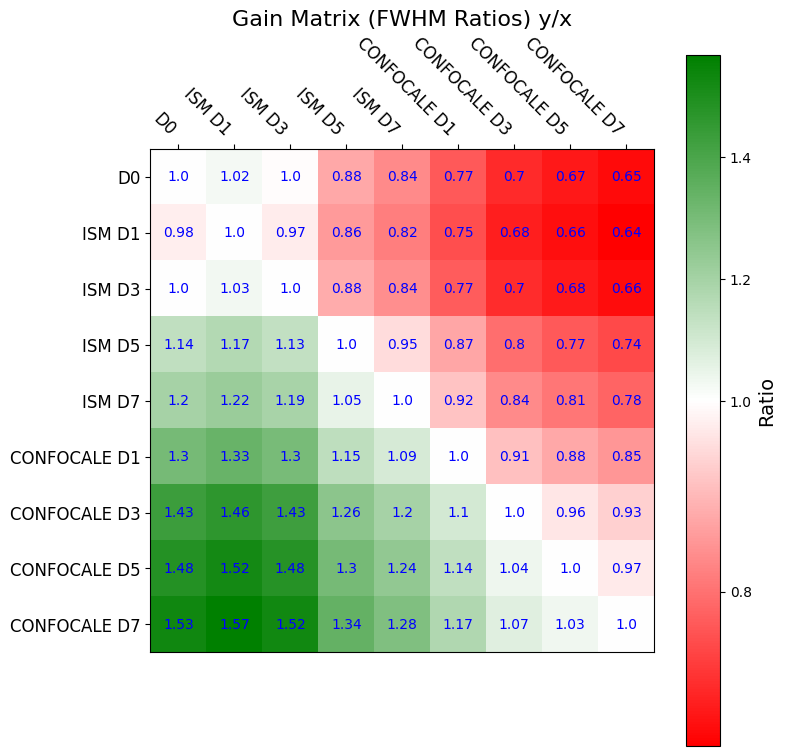

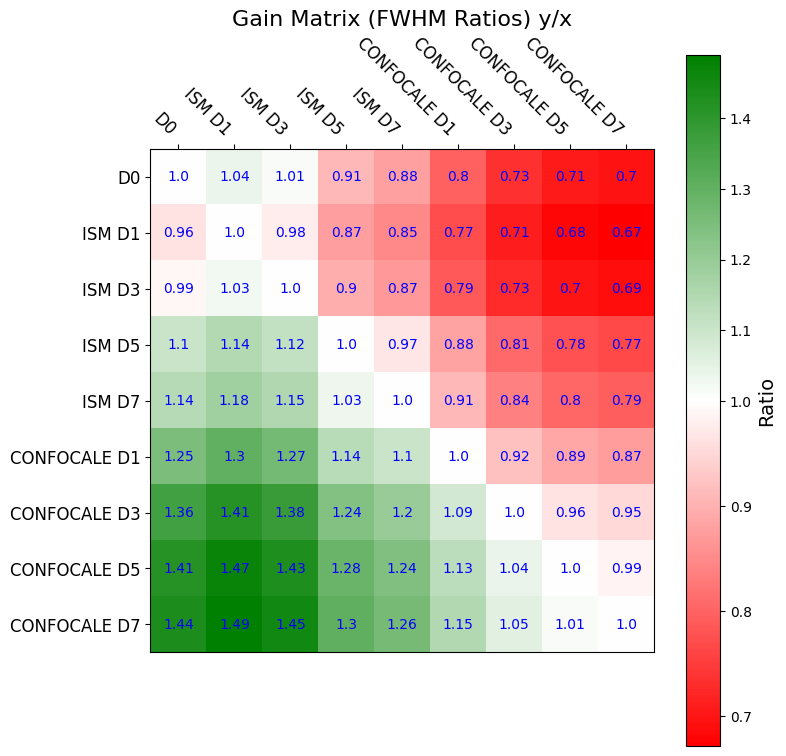

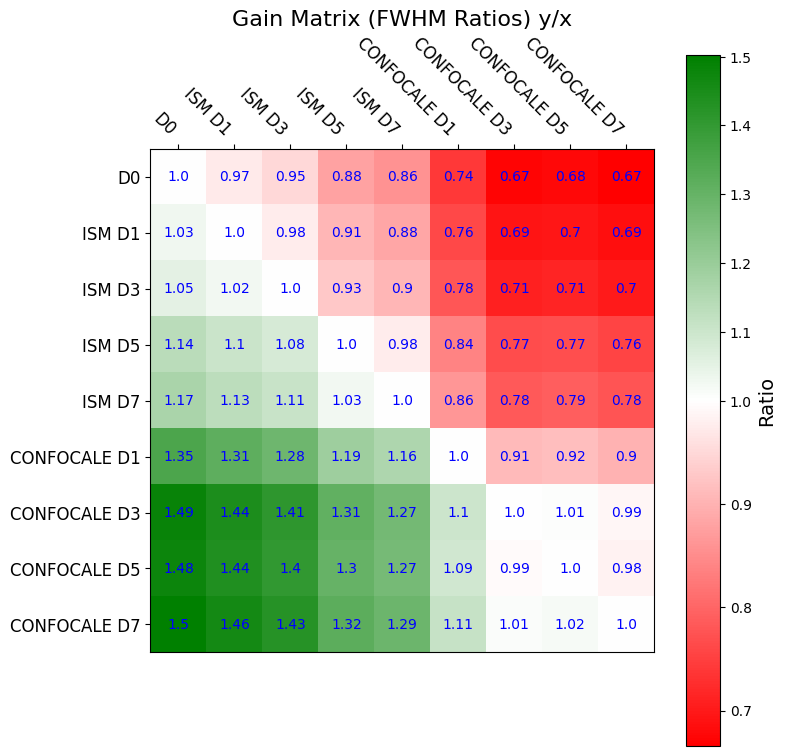

In [220]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

for index in range(len(result)):
    filter = ['D0', 'ISM D1', 'ISM D3', 'ISM D5', 'ISM D7', 'CONFOCALE D1', 'CONFOCALE D3', 'CONFOCALE D5', 'CONFOCALE D7']
    compar = {k: result[index][k] for k in filter if k in result[0]}  # Take the first dictionary from the list
    # print(compar)

    labels = list(compar.keys())
    matrix_guadagno = np.zeros((len(labels), len(labels)))

    for k, v in enumerate(compar.values()):
        for l, w in enumerate(compar.values()):
            matrix_guadagno[k, l] = np.round(v / w, 4)

    cmap = LinearSegmentedColormap.from_list('red_white_green', ['red', 'white', 'green'])
    norm = TwoSlopeNorm(vmin=matrix_guadagno.min(), vcenter=1.0, vmax=matrix_guadagno.max())

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(matrix_guadagno,  cmap=cmap, norm=norm)

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Ratio', fontsize=14)

    # Set axis labels and ticks
    ax.set_xticks(np.arange(len(labels)))
    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=-45, ha='right', fontsize=12)
    ax.set_yticklabels(labels, fontsize=12)
    #ax.set_xlabel('Compared', fontsize=14)
    #ax.set_ylabel('Reference', fontsize=14)
    ax.set_title('Gain Matrix (FWHM Ratios) y/x', fontsize=16)

    # Annotate values
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{np.round(matrix_guadagno[i, j], 2)}", ha="center", va="center", color="blue", fontsize=10)

    plt.tight_layout()
    plt.show()

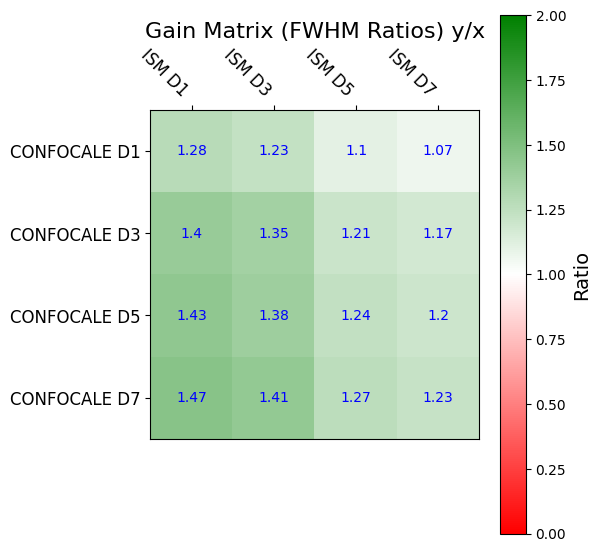

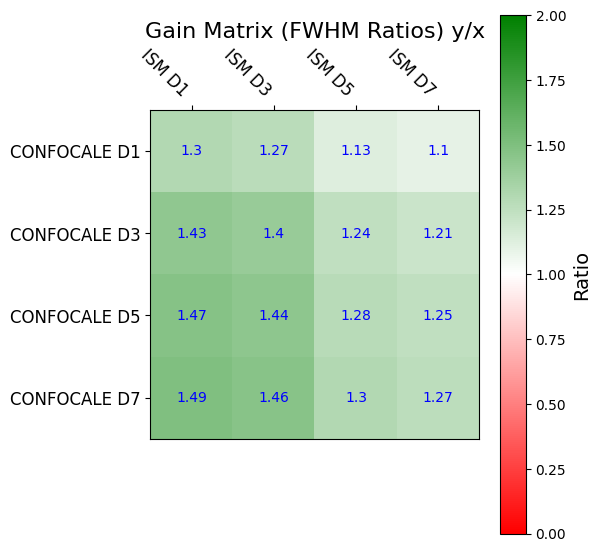

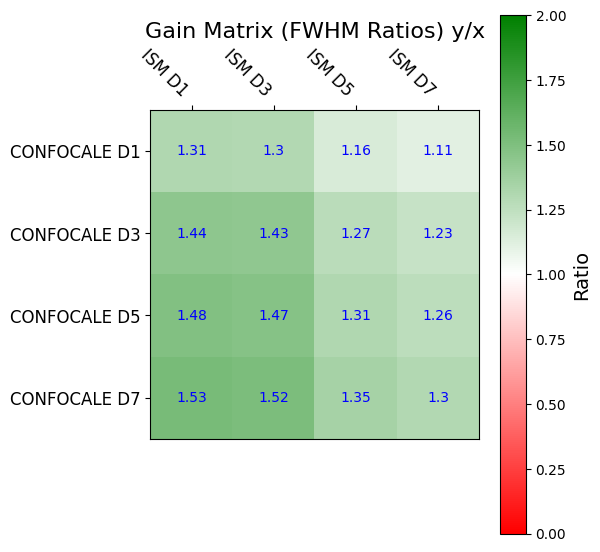

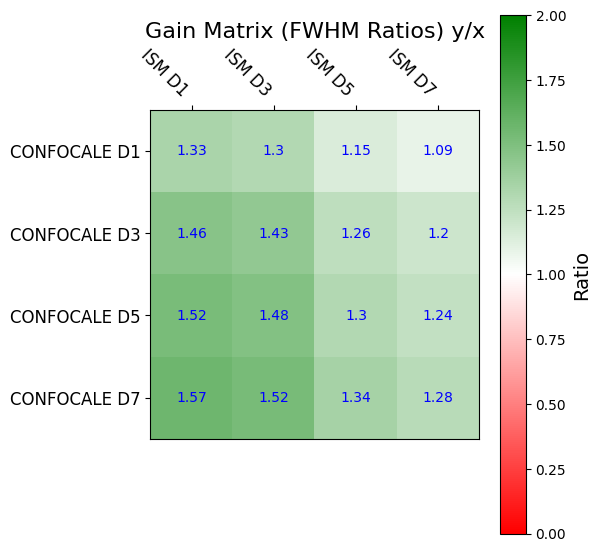

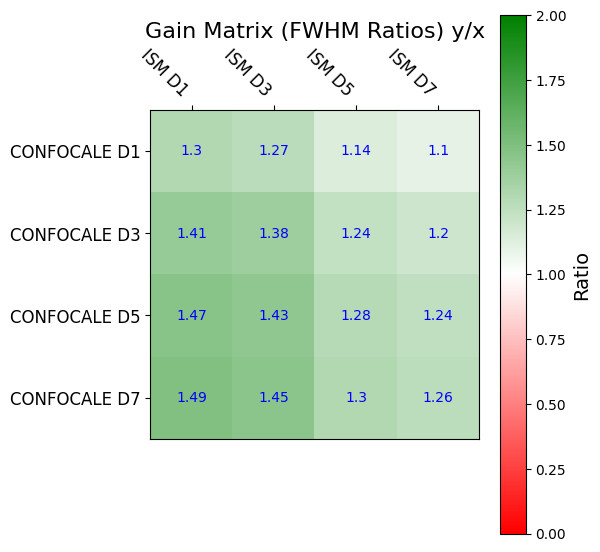

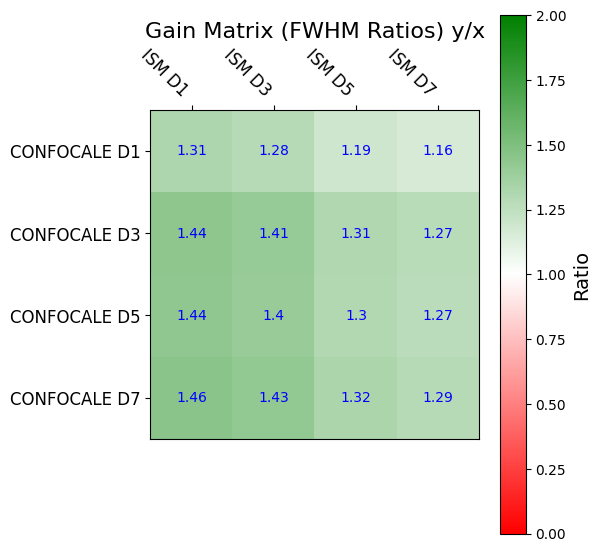

In [221]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap



for index in range(len(result)):
    filterx = ['ISM D1', 'ISM D3', 'ISM D5', 'ISM D7']
    comparx = {k: result[index][k] for k in filterx if k in result[index]}  # Take the first dictionary from the list
    filtery = ['CONFOCALE D1', 'CONFOCALE D3', 'CONFOCALE D5', 'CONFOCALE D7']
    compary = {k: result[index][k] for k in filtery if k in result[index]}  # Take the first dictionary from the list

    labelsx = list(comparx.keys())
    labelsy = list(compary.keys())

    matrix_guadagno = np.zeros((len(labelsx), len(labelsy)))

    for k, v in enumerate(compary.values()):
        for l, w in enumerate(comparx.values()):
            matrix_guadagno[k, l] = np.round(v / w, 4)
    
    cmap = LinearSegmentedColormap.from_list('red_white_green', ['red', 'white', 'green'])
    try:
        norm = TwoSlopeNorm(vmin=matrix_guadagno.min(), vcenter=1.0, vmax=matrix_guadagno.max())
    except:
        norm = TwoSlopeNorm(vmin=0, vcenter=1.0, vmax=2)

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(matrix_guadagno,  cmap=cmap, norm=norm)

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Ratio', fontsize=14)

    # Set axis labels and ticks


    ax.set_xticks(np.arange(len(labelsx)))
    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.set_yticks(np.arange(len(labelsy)))
    ax.set_xticklabels(labelsx, rotation=-45, ha='right', fontsize=12)
    ax.set_yticklabels(labelsy, fontsize=12)
    #ax.set_xlabel('Compared', fontsize=14)
    #ax.set_ylabel('Reference', fontsize=14)
    ax.set_title('Gain Matrix (FWHM Ratios) y/x', fontsize=16)

    # Annotate values
    for i in range(len(labelsy)):
        for j in range(len(labelsx)):
            ax.text(j, i, f"{np.round(matrix_guadagno[i, j], 2)}", ha="center", va="center", color="blue", fontsize=10)

    plt.tight_layout()
    plt.show()

signal to background ratio

In [222]:
BKG_ISM1 = ISM_D1[20:30,20:30].mean()
BKG_ISM3 = ISM_D3[20:30,20:30].mean()
BKG_ISM5 = ISM_D5[20:30,20:30].mean()
BKG_ISM7 = ISM_D7[20:30,20:30].mean()
BKG_sum1 = sum_D1[20:30,20:30].mean()
BKG_sum3 = sum_D3[20:30,20:30].mean()
BKG_sum5 = sum_D5[20:30,20:30].mean()
BKG_sum7 = sum_D7[20:30,20:30].mean()

signal_ISM_1 = ISM_D1[xc_D1[ROI_TO_ANALYSE['ROI_D1'],0], xc_D1[ROI_TO_ANALYSE['ROI_D1'],1]]
signal_ISM_3 = ISM_D3[xc_D3[ROI_TO_ANALYSE['ROI_D3'],0], xc_D3[ROI_TO_ANALYSE['ROI_D3'],1]]
signal_ISM_5 = ISM_D5[xc_D5[ROI_TO_ANALYSE['ROI_D5'],0], xc_D5[ROI_TO_ANALYSE['ROI_D5'],1]]
signal_ISM_7 = ISM_D7[xc_D7[ROI_TO_ANALYSE['ROI_D7'],0], xc_D7[ROI_TO_ANALYSE['ROI_D7'],1]]
signal_sum_1 = sum_D1[xc_sum_D1[ROI_TO_ANALYSE['ROI_sum_D1'],0], xc_sum_D1[ROI_TO_ANALYSE['ROI_sum_D1'],1]]
signal_sum_3 = sum_D3[xc_sum_D3[ROI_TO_ANALYSE['ROI_sum_D3'],0], xc_sum_D3[ROI_TO_ANALYSE['ROI_sum_D3'],1]]
signal_sum_5 = sum_D5[xc_sum_D5[ROI_TO_ANALYSE['ROI_sum_D5'],0], xc_sum_D5[ROI_TO_ANALYSE['ROI_sum_D5'],1]]
signal_sum_7 = sum_D7[xc_sum_D7[ROI_TO_ANALYSE['ROI_sum_D7'],0], xc_sum_D7[ROI_TO_ANALYSE['ROI_sum_D7'],1]]

SBG_ISM_1 = signal_ISM_1 / BKG_ISM1
SBG_ISM_3 = signal_ISM_3 / BKG_ISM3
SBG_ISM_5 = signal_ISM_5 / BKG_ISM5
SBG_ISM_7 = signal_ISM_7 / BKG_ISM7
SBG_sum_1 = signal_sum_1 / BKG_sum1
SBG_sum_3 = signal_sum_3 / BKG_sum3
SBG_sum_5 = signal_sum_5 / BKG_sum5
SBG_sum_7 = signal_sum_7 / BKG_sum7

print("Signal-to-Background Ratio (SBG):")
print("ISM D1:", SBG_ISM_1)
print("ISM D3:", SBG_ISM_3)
print("ISM D5:", SBG_ISM_5)
print("ISM D7:", SBG_ISM_7)
print("Confocal D1:", SBG_sum_1)
print("Confocal D3:", SBG_sum_3)
print("Confocal D5:", SBG_sum_5)
print("Confocal D7:", SBG_sum_7)

print('-------------GUADAGNI---------------')
print("SBG Confocal D1 / SBG ISM D1:", SBG_ISM_1 / SBG_sum_1)
print("SBG Confocal D3 / SBG ISM D3:", SBG_ISM_3 / SBG_sum_3)
print("SBG Confocal D5 / SBG ISM D5:", SBG_ISM_5 / SBG_sum_5)
print("SBG Confocal D7 / SBG ISM D7:", SBG_ISM_7 / SBG_sum_7)

# Calculate mean and std of SBG gain (Confocal/ISM) for each D
gain_D1 = 1/(SBG_sum_1 / SBG_ISM_1)
gain_D3 = 1/(SBG_sum_3 / SBG_ISM_3)
gain_D5 = 1/(SBG_sum_5 / SBG_ISM_5)
gain_D7 = 1/(SBG_sum_7 / SBG_ISM_7)

print("\nMean and Std of SBG Gain (Confocal/ISM):")
print(f"D1: {np.round(gain_D1.mean(), 2)} ± {np.round(gain_D1.std(), 2)}")
print(f"D3: {np.round(gain_D3.mean(), 2)} ± {np.round(gain_D3.std(), 2)}")
print(f"D5: {np.round(gain_D5.mean(), 2)} ± {np.round(gain_D5.std(), 2)}")
print(f"D7: {np.round(gain_D7.mean(), 2)} ± {np.round(gain_D7.std(), 2)}")

Signal-to-Background Ratio (SBG):
ISM D1: [13.61662531  8.82961125  8.7417287   6.9633995   7.09780811  5.66066998]
ISM D3: [10.31542592  6.65389493  6.72674779  5.36412941  5.2939748   4.31990502]
ISM D5: [6.04909179 3.9553055  3.86735971 3.2427191  3.2427191  2.8187753 ]
ISM D7: [3.95415174 2.70784755 2.62395056 2.28604822 2.28141942 2.07312346]
Confocal D1: [9.48855989 5.69417124 5.55440522 5.06263588 4.48286572 4.05321462]
Confocal D3: [6.57113558 4.0830095  4.00744819 3.68091537 3.33549223 2.96038428]
Confocal D5: [4.49829721 2.88346602 2.75265568 2.67597375 2.34894788 2.29933016]
Confocal D7: [3.0497648  2.11649396 2.03259794 1.96200957 1.81793986 1.77570256]
-------------GUADAGNI---------------
SBG Confocal D1 / SBG ISM D1: [1.43505711 1.55064027 1.57383705 1.3754494  1.58331936 1.39658777]
SBG Confocal D3 / SBG ISM D3: [1.56980872 1.62965453 1.67856139 1.45728137 1.58716448 1.45923793]
SBG Confocal D5 / SBG ISM D5: [1.34475147 1.37171913 1.40495586 1.21179033 1.38049853 1.22591

In [243]:
import pandas as pd

# signal to background ratio:

images = np.array([CENTRAL_D0, ISM_D1, ISM_D3, ISM_D5, ISM_D7, sum_D1, sum_D3, sum_D5, sum_D7])

maxes = np.array([np.max(img) for img in images])

voids = np.array([img[20:30,20:30].mean() for img in images])
SBG = maxes / voids
# Define labels for each image
labels = ['D0', 'ISM D1', 'ISM D3', 'ISM D5', 'ISM D7', 'CONF D1', 'CONF D3', 'CONF D5', 'CONF D7']

# Create DataFrame with only 'Image' and 'SBG' columns
df_SBG_simple = pd.DataFrame({
    'Image': labels,
    'SBG': np.round(SBG, 2)
})

display(df_SBG_simple.T)


,0,1,2,3,4,5,6,7,8
Image,D0,ISM D1,ISM D3,ISM D5,ISM D7,CONF D1,CONF D3,CONF D5,CONF D7
SBG,21.08,13.62,10.32,6.05,3.95,9.49,6.57,4.5,3.05


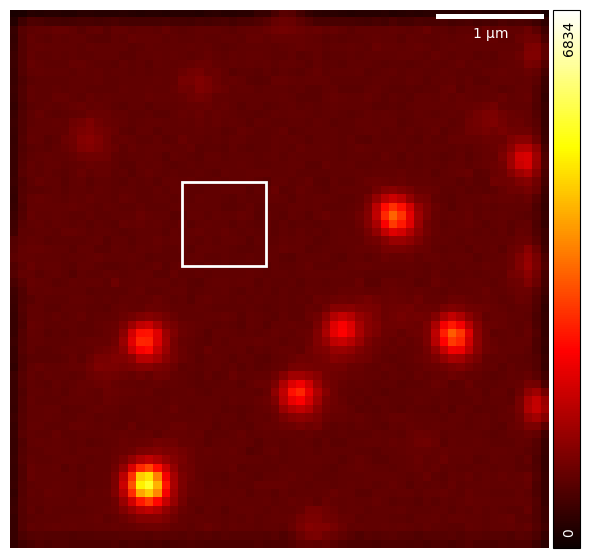

In [238]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
mincolor = 0
maxcolor = np.max(ISM_D7)

im = gra.ShowImg(ISM_D5, pxsize_x = pxsizex, fig = fig, ax = ax, cmap='hot', colorbar=True,vmin=mincolor, vmax=maxcolor) #[422:512,45:135]

rect = Rectangle((20, 20), 10, 10, linewidth=2, edgecolor='white', facecolor='none')
ax.add_patch(rect)
# fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
#plt.imshow(ISM_D5, cmap='hot', vmin=mincolor, vmax=maxcolor)
plt.show()

# ANALISI DEI DATI RACCOLTI DI TUTTI

In [223]:
ISM_DATAFRAME = pd.read_csv('./images/ISM/ISM_FWHM.csv')
display(ISM_DATAFRAME)

,FILE,D0,ISM D1,ISM D3,ISM D5,ISM D7,CONFOCALE D1,CONFOCALE D3,CONFOCALE D5,CONFOCALE D7,...,err CONFOCALE D7,ROI D0,ROI ISM D1,ROI ISM D3,ROI ISM D5,ROI ISM D7,ROI CONFOCALE D1,ROI CONFOCALE D3,ROI CONFOCALE D5,ROI CONFOCALE D7
0,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,266.0,270.0,280.0,313.0,323.0,345.0,379.0,387.0,396.0,...,3.0,0,0,0,0,0,0,0,0,0
1,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,272.0,265.0,271.0,305.0,313.0,344.0,379.0,390.0,396.0,...,5.0,1,1,2,1,1,1,1,1,1
2,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,273.0,260.0,262.0,295.0,306.0,341.0,375.0,386.0,397.0,...,6.0,2,2,1,2,2,2,2,2,2
3,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,260.0,254.0,261.0,296.0,311.0,339.0,372.0,386.0,398.0,...,7.0,3,4,3,3,3,3,3,3,3
4,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,246.0,237.0,243.0,271.0,280.0,308.0,335.0,348.0,353.0,...,20.0,4,3,4,4,4,4,4,4,4
5,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2,241.0,248.0,254.0,274.0,281.0,326.0,358.0,356.0,362.0,...,23.0,5,5,5,5,5,5,5,5,5
6,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI3,227.0,231.0,247.0,260.0,270.0,284.0,304.0,301.0,311.0,...,5.0,0,0,0,0,0,0,0,0,0
7,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI3,217.0,222.0,241.0,262.0,270.0,282.0,302.0,304.0,310.0,...,14.0,1,1,1,1,1,1,1,1,1
8,Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI3,278.0,294.0,310.0,326.0,339.0,339.0,363.0,362.0,375.0,...,10.0,5,5,4,3,3,2,2,2,2


Mean G_D1: 1.28 ± 0.05
Mean G_D3: 1.34 ± 0.09
Mean G_D5: 1.24 ± 0.07
Mean G_D7: 1.22 ± 0.07


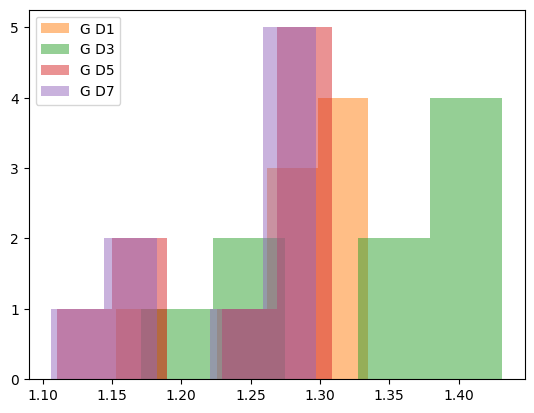

In [224]:
G_D1 = ISM_DATAFRAME['CONFOCALE D1'] / ISM_DATAFRAME['ISM D1']
G_D3 = ISM_DATAFRAME['CONFOCALE D3'] / ISM_DATAFRAME['ISM D3']
G_D5 = ISM_DATAFRAME['CONFOCALE D5'] / ISM_DATAFRAME['ISM D5']
G_D7 = ISM_DATAFRAME['CONFOCALE D7'] / ISM_DATAFRAME['ISM D7']

print(f"Mean G_D1: {np.mean(G_D1):.2f} ± {np.std(G_D1):.2f}")
print(f"Mean G_D3: {np.mean(G_D3):.2f} ± {np.std(G_D3):.2f}")
print(f"Mean G_D5: {np.mean(G_D5):.2f} ± {np.std(G_D5):.2f}")
print(f"Mean G_D7: {np.mean(G_D7):.2f} ± {np.std(G_D7):.2f}")

plt.hist(G_D1, bins=5, alpha=0.5, label='G D1', color='tab:orange')
plt.hist(G_D3, bins=5, alpha=0.5, label='G D3', color='tab:green')
plt.hist(G_D5, bins=5, alpha=0.5, label='G D5', color='tab:red')
plt.hist(G_D7, bins=5, alpha=0.5, label='G D7', color='tab:purple')
plt.legend()
plt.show()

- analizzare ROI 2
- riportare fingerprint
- discorso segnale per correlazioni nella roi 2 (L'ism funziona sofi no)
- mostrare il blinking per confermare scala temporale ( più immagini stessa sequenza temporale)
